<a href="https://colab.research.google.com/github/profsuccodifrutta/ai_act_RAG_navigator/blob/main/public_pipeline_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CREATION OF ENVIRONMENT

In [ ]:
#  GITHUB REPOSITORY SETUP
import os

# Configuration for GitHub
GIT_USER = "profsuccodifrutta"
GIT_REPO = "ai_act_RAG_navigator"
REPO_URL = f"https://github.com/{GIT_USER}/{GIT_REPO}.git"

# Clone repo
if not os.path.exists(GIT_REPO):
    print(f"Cloning repository {GIT_REPO}...")
    !git clone {REPO_URL}
else:
    print(f"Folder {GIT_REPO} already exists.")

# Move into the repo directory
%cd {GIT_REPO}

Cloning repository ai_act_RAG_navigator...
Cloning into 'ai_act_RAG_navigator'...
remote: Enumerating objects: 214, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 214 (delta 36), reused 0 (delta 0), pack-reused 157 (from 1)
Receiving objects: 100% (214/214), 3.16 MiB | 7.38 MiB/s, done.
Resolving deltas: 100% (129/129), done.
/content/ai_act_RAG_navigator


In [ ]:
#  SYSTEM SETUP and DEPENDENCIES
!curl -LsSf https://astral.sh/uv/install.sh | sh
import sys
import os

# Add uv to PATH
sys.path.append("/root/.cargo/bin")

# Initialize uv
if not os.path.exists("pyproject.toml"):
    !uv init
else:
    print("uv already initialized.")


!uv add langchain langchain-community langchain-google-genai faiss-cpu pymupdf spacy python-dotenv langchain-text-splitters langchain-core datasets sentence-transformers rank_bm25 pandas matplotlib scikit-learn plotly scipy tensorflow accelerate
!uv pip install --system langchain langchain-community langchain-google-genai faiss-cpu pymupdf spacy python-dotenv langchain-text-splitters langchain-core datasets sentence-transformers rank_bm25 pandas matplotlib scikit-learn plotly scipy tensorflow accelerate
print("\nEnvironment configuration completed!")

downloading uv 0.11.2 x86_64-unknown-linux-gnu
installing to /usr/local/bin
  uv
  uvx
everything's installed!
uv already initialized.
Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 172 packages in 1.25s
Prepared 169 packages in 50.85s
Installed 169 packages in 686ms
 + absl-py==2.4.0
 + accelerate==1.13.0
 + aiohappyeyeballs==2.6.1
 + aiohttp==3.13.3
 + aiosignal==1.4.0
 + annotated-doc==0.0.4
 + annotated-types==0.7.0
 + anyio==4.12.1
 + astunparse==1.6.3
 + attrs==25.4.0
 + blis==1.3.3
 + catalogue==2.0.10
 + certifi==2026.1.4
 + cffi==2.0.0
 + charset-normalizer==3.4.4
 + click==8.3.1
 + cloudpathlib==0.23.0
 + confection==0.1.5
 + contourpy==1.3.3
 + cryptography==46.0.5
 + cuda-bindings==13.2.0
 + cuda-pathfinder==1.5.0
 + cuda-toolkit==13.0.2
 + cycler==0.12.1
 + cymem==2.0.13
 + dataclasses-json==0.6.7
 + datasets==4.8.4
 + dill==0.4.1
 + distro==1.9.0
 + faiss-cpu==1.13.2
 + filelock==3.25.2
 + filetype==1.2.0
 + flatbuff

# LOADING LIBRARIES

In [ ]:
from google.colab import drive
import os
import requests
import shutil
import fitz  # This is PyMuPDF
import re
import pandas as pd
import matplotlib.pyplot as plt
import gc
import random
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
from spacy import displacy
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
import plotly.graph_objects as go
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import plotly.io as pio
import plotly.express as px
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score
from scipy.special import softmax
from langchain_classic.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever
from collections import defaultdict
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, TextVectorization, Input, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import PolynomialDecay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [ ]:
#  DATA & RAG CONFIGURATION
import os
t
local_pdf_path = "ai_act_2024.pdf"

if os.path.exists(local_pdf_path):
    print(f"PDF successfully found locally at: {local_pdf_path}")
else:
    print(f"Error: The file '{local_pdf_path}' was not found.")

# Local persistence folder for FAISS index
local_persistence_path = "ai_act_rag_index"
if not os.path.exists(local_persistence_path):
    os.makedirs(local_persistence_path)
    print("Folder for index persistence ready locally.")
else:
    print("Folder for index persistence already exists.")

PDF successfully found locally at: ai_act_2024.pdf
Folder for index persistence ready locally.


# OVERVIEW

The primary objective of this project is to enable generative AI to operate reliably within a legal compliance context, with a specific focus on the EU AI Act. Standard large language models, while powerful, are not inherently aligned with regulatory frameworks and may produce inaccurate or misleading legal interpretations. This makes them unsuitable for compliance-critical applications. To overcome this limitation, we designed an advanced, risk-aware Retrieval Augmented Generation (RAG) system.

The system begins by using a dedicated machine learning classifier to assign each user-provided business use case to one of the official AI Act risk categories. This predicted risk level is then used to guide a custom hybrid retrieval engine, which selects only the most relevant legal provisions based on both the user’s context and stakeholder role. By filtering and narrowing the information passed to the model before generation, the system constrains the LLM within a well-defined factual boundary. As a result, the architecture acts as a reliable compliance assistant, providing responses grounded in specific legal sources, with traceable references, while significantly reducing the risk of hallucination.

# PRE-PROCESSING and EDA

The parse_ai_act_robust() function is designed to convert the EU AI Act PDF into a structured collection of clean legal units that can be used in the downstream RAG pipeline. It first opens the document page by page and removes formatting noise, such as page headers, document references, isolated page numbers, and hyphenation introduced by line breaks. It then applies a regular-expression based cleaning step to identify and remove footnote blocks, preventing them from being incorrectly merged with the main legal text.

After this preprocessing stage, the function assigns each page to one of three macro-sections of the document: RECITAL, ARTICLE, or ANNEX,according to its position in the PDF. The cleaned text within each section is then concatenated and split only at valid structural boundaries: numbered recitals, article headings, and annex titles. This avoids erroneous splits when references such as “Article 99” appear inside a sentence rather than as true section headers.

The final output is a pandas DataFrame in which each row corresponds to one complete legal unit, identified by its section label and associated category. This structured representation provides a much cleaner and more reliable foundation for chunking, metadata enrichment, and retrieval in the RAG system.  

In [ ]:
def parse_ai_act_robust(pdf_path):
    doc = fitz.open(pdf_path)

    categories_text = {
        "RECITAL": [],
        "ARTICLE": [],
        "ANNEX": []
    }

    noise_pattern = re.compile(r"(\d+/144|ELI: http://data\.europa\.eu/eli/reg/.+|OJ L, 12\.7\.2024|EN|\(Text with EEA relevance\))")
    footnote_cleaner = re.compile(r"\n\s*\(\s*\d+\s*\)\s*(?:OJ\b|Position\b|Directive\b|Regulation\b|See\b|Case\b).*$", re.IGNORECASE | re.DOTALL)

    footnotes_removed = 0

    for page_num in range(len(doc)):
        text = doc[page_num].get_text("text").replace("-\n", "")

        clean_lines = []
        for line in text.split("\n"):
            cleaned_line = noise_pattern.sub("", line).strip()
            if cleaned_line and not cleaned_line.isdigit():
                clean_lines.append(cleaned_line)

        # Join the page back together
        final_page_text = "\n" + "\n".join(clean_lines)

        if footnote_cleaner.search(final_page_text):
            # Replace the footnote block with a single newline
            final_page_text = footnote_cleaner.sub("\n", final_page_text)
            footnotes_removed += 1

        p_idx = page_num + 1
        if p_idx < 44:
            categories_text["RECITAL"].append(final_page_text)
        elif 44 <= p_idx <= 123:
            categories_text["ARTICLE"].append(final_page_text)
        else:
            categories_text["ANNEX"].append(final_page_text)

    doc.close()
    print(f"Removed footnote blocks from {footnotes_removed} pages.")

    units = []

    # proces recitals
    recital_text = "\n" + "\n".join(categories_text["RECITAL"]) + "\n"
    rec_parts = re.split(r"\n\s*\(\s*(\d+)\s*\)\s+", recital_text)
    for i in range(1, len(rec_parts), 2):
        text_content = rec_parts[i+1].replace("\n", " ").strip()
        if text_content:
            units.append({"id": f"RECITAL {rec_parts[i]}", "category": "RECITAL", "text": text_content})

    # proces articles
    article_text = "\n" + "\n".join(categories_text["ARTICLE"]) + "\n"
    art_parts = re.split(r"(?i)\n\s*Article\s+(\d+)\s*\n", article_text)
    for i in range(1, len(art_parts), 2):
        text_content = art_parts[i+1].replace("\n", " ").strip()
        if text_content:
            units.append({"id": f"ARTICLE {art_parts[i]}", "category": "ARTICLE", "text": text_content})

    # proces annexes
    annex_text = "\n" + "\n".join(categories_text["ANNEX"]) + "\n"
    annex_parts = re.split(r"(?i)\n\s*ANNEX\s+([IVXLCDM]+)\s*\n", annex_text)
    for i in range(1, len(annex_parts), 2):
        text_content = annex_parts[i+1].replace("\n", " ").strip()
        if text_content:
            units.append({"id": f"ANNEX {annex_parts[i].upper()}", "category": "ANNEX", "text": text_content})

    return pd.DataFrame(units)

In [ ]:
df_units = parse_ai_act_robust(local_pdf_path)
df_units['len'] = df_units['text'].str.len()

print(f"Clean Units created: {len(df_units)}")
print(f"Max length: {df_units['len'].max()}")

Removed footnote blocks from 23 pages.
Clean Units created: 307
Max length: 17095


An embedding vector encodes the overall meaning of a text segment. When a chunk is too long and contains multiple legal concepts, this representation becomes less precise, as different topics are compressed into a single vector. As a result, it becomes harder for the retrieval system to identify and match the specific information relevant to a query.

In addition, even if a large language model can process long passages, including too much irrelevant content introduces noise in the context. This can reduce the quality of the generated response, increasing the risk of overlooking key details or producing inaccurate outputs.

For this reason, chunk size must be carefully controlled. In the following section, the distribution of chunk lengths is analyzed to support an appropriate calibration.

In [ ]:
avg_len = df_units['len'].mean()

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=df_units['len'],
    nbinsx=50,
    marker_color='#e74c3c',
    marker_line=dict(color='white', width=1),
    name='Unit Lengths'
))

fig.add_vline(x=1500, line_dash="dash", line_color="#c0392b")

fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='lines',
    line=dict(color='#c0392b', dash='dash'),
    name='Target RAG Limit (1500)'
))

fig.add_vline(x=avg_len, line_dash="solid", line_color="#f39c12")

fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='lines',
    line=dict(color='#f39c12', shape='linear'),
    name=f'Average Length ({avg_len:.0f})'
))

fig.update_layout(
    title='<b>Distribution of Legal Unit Lengths </b>',
    xaxis_title="Characters",
    yaxis_title="Number of Units",
    template='plotly_white',
    bargap=0.05,
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99,
        bgcolor="rgba(255, 255, 255, 0.5)"
    ),
    height=500
)


fig.show()

# METADATA ENRICHMENT WITH ERROR ANALYSIS

**NER FOR ENRICHING THE METADATA**


In a standard RAG system, the database relies entirely on dense vector embeddings to find relevant information. While vectors are excellent at understanding the semantic meaning or general theme of a question, they struggle significantly with exact keyword matching. For example, a vector search might easily confuse the legal obligations of a "Provider" with those of a "Deployer" because both concepts occupy a very similar mathematical space in the vector database.

**ERROR ANALYSIS METHODOLOGY**


Identifying and extracting these entities requires an iterative methodology that we'll call Error Analysis, as relying entirely on pre-trained machine learning models, this case of domain specific legal text will lead to systemic failures. Pre-trained NLP models calculate statistical probabilities based on everyday internet text, they get easily confused by the dense capitalization, roman numerals, and acronyms found in the AI Act.

To overcome this, we established an iterative feedback loop:


1.   Baseline Definition: We injected a baseline set of deterministic rules (the EntityRuler) into the pipeline before the machine learning component.
2.   Visual Diagnostics: We ran random samples of the text through the pipeline and used a visualizer (displaCy) to inspect the model's behavior.
3. Identifying False Positives and Negatives: By reading the annotated text, we spotted areas where the model missed critical terms.
4. Rule Calibration: We updated our deterministic rules to either explicitly classify these edge cases (e.g. assigning "Annexes" to DOCUMENT)


The rules that drive this extraction are defined in a simple but highly powerful list called patterns. Every rule is a dictionary containing two key-value pairs: the "label" (which dictates the category, like "ORG" or "RISK_LEVEL") and the "pattern" (which defines what text to look for).

Afther the pattern have been identified they are added to the document object of langchain library, since could be useful to exploit these information while retriving, possibly increasing the rag system performance.

In [ ]:
nlp = spacy.load("en_core_web_sm")

ruler = nlp.add_pipe("entity_ruler", before="ner") # ner = spacy module for ner
                                                   # before the model prediction

patterns = [
    # organizations and authoroties
    {"label": "ORG", "pattern": "AI Office"},
    {"label": "ORG", "pattern": "European Artificial Intelligence Board"},
    {"label": "ORG", "pattern": "Market Surveillance Authority"},
    {"label": "ORG", "pattern": [{"lower": "european"}, {"lower": "commission"}]},
    {"label": "ORG", "pattern": "European Data Protection Board"},
    {"label": "ORG", "pattern": "European Data Protection Supervisor"},
    {"label": "ORG", "pattern": "EDPB"},
    {"label": "ORG", "pattern": "EDPS"},
    {"label": "ORG", "pattern": "Board"},
    {"label": "ORG", "pattern": "Commission"},

    # geopolitical entities
    {"label": "GPE", "pattern": "Union"},
    {"label": "GPE", "pattern": "EU"},

    # documents
    {"label": "DOCUMENT", "pattern": "Regulation"},
    {"label": "DOCUMENT", "pattern": "Directive"},
    {"label": "DOCUMENT", "pattern": [{"lower": "annex"}, {"IS_ALPHA": True, "IS_UPPER": True}]},
    {"label": "DOCUMENT", "pattern": [{"lower": "annexes"}, {"IS_ALPHA": True, "IS_UPPER": True}]},

    # Chapters
    {"label": "LAW", "pattern": [{"lower": "chapter"}, {"IS_DIGIT": True}]},
    {"label": "LAW", "pattern": [{"lower": "chapter"}, {"IS_ALPHA": True, "IS_UPPER": True}]},

    # Sections
    {"label": "LAW", "pattern": [{"lower": "section"}, {"IS_DIGIT": True}]},
    {"label": "LAW", "pattern": [{"lower": "section"}, {"IS_ALPHA": True, "IS_UPPER": True}]},
    {"label": "LAW", "pattern": [{"lower": "sections"}, {"IS_DIGIT": True}]},
    {"label": "LAW", "pattern": [{"lower": "sections"}, {"IS_ALPHA": True, "IS_UPPER": True}]},

    # Articles
    {"label": "LAW", "pattern": [{"lower": "article"}, {"IS_DIGIT": True}]},

    # ignore these patterns
    {"label": "IGNORE", "pattern": "AI"},
    {"label": "IGNORE", "pattern": [{"lower": "artificial"}, {"lower": "intelligence"}]},
    {"label": "IGNORE", "pattern": [{"lower": "ai"}, {"lower": "system"}]},

    # concepts and legal roles
    {"label": "CONCEPT", "pattern": "CE"},
    {"label": "CONCEPT", "pattern": [{"text": "CE"}, {"lower": "marking"}]},
    {"label": "CONCEPT", "pattern": [{"lower": "general"}, {"IS_PUNCT": True, "OP": "?"}, {"lower": "purpose"}, {"lower": "ai"}]},
    {"label": "LEGAL_ROLE", "pattern": [{"lower": "provider"}]},
    {"label": "LEGAL_ROLE", "pattern": [{"lower": "providers"}]},
    {"label": "LEGAL_ROLE", "pattern": [{"lower": "deployer"}]},
    {"label": "LEGAL_ROLE", "pattern": [{"lower": "deployers"}]},
    # risk levels
    {"label": "RISK_LEVEL", "pattern": [{"lower": "high"}, {"IS_PUNCT": True, "OP": "?"}, {"lower": "risk"}]},
    {"label": "RISK_LEVEL", "pattern": [{"lower": "unacceptable"}, {"lower": "risk"}]},
    {"label": "RISK_LEVEL", "pattern": [{"lower": "limited"}, {"lower": "risk"}]},
    {"label": "RISK_LEVEL", "pattern": [{"lower": "minimal"}, {"lower": "risk"}]},
]

ruler.add_patterns(patterns)

**LANGCHAIN DOCOMUNENT OBJECT EXPANSION**


LangChain wraps every chunk of the text into a specific Python object called a Document, it has exactly two parts:


1.   page_content: A single string of text
2.   metadata: A standard Python Dictionary

RecursiveCharacterTextSplitter() slices the text into chunks of up to 1500 characters, maintaining a 200-character overlap to ensure no nuanced legal context is lost at the boundaries. It applies "contextual chunking" by prepending the exact legal identifier (such as [ARTICLE 10]) directly into the text of every single slice, this guarantees that the LLM always knows exactly which part of the law it is referencing. Then it packages each segment into a LangChain Document object and enriches it with structured metadata, including the category, legal unit, and a flag indicating if it is a continuation resulting in a robust, searchable dataset ready for embedding into the FAISS vector database.

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,
    chunk_overlap=200,
    length_function=len,
    separators=["\n\n", "\n", ".", " ", ""]
)

final_documents = []


for _, row in df_units.iterrows():
    unit_id = row['id']
    category = row['category']
    text = row['text']

    chunks = text_splitter.split_text(text)

    for i, chunk in enumerate(chunks):
        enriched_content = f"[{unit_id}] {chunk}"

        combined_metadata = {
            "source": "EU_AI_Act_2024",
            "category": category,
            "legal_unit": unit_id,
            "chunk_index": i,
            "is_continuation": i > 0
        }

        spacy_doc = nlp(enriched_content)
        extracted = defaultdict(set)

        for ent in spacy_doc.ents:
            if ent.label_ != "IGNORE":
                extracted[ent.label_].add(ent.text)

        for label, entity_set in extracted.items():
            combined_metadata[f"ner_{label}"] = list(entity_set)

        doc = Document(
            page_content=enriched_content,
            metadata=combined_metadata
        )

        final_documents.append(doc)

print(f"Total vectorized chunks: {len(final_documents)}")

Total vectorized chunks: 577


Check of the information a single chunk is holding:

In [ ]:
sample_doc = random.choice(final_documents)

for key, value in sample_doc.metadata.items():
    if not key.startswith("ner_"):
        clean_key = key.replace('_', ' ').title()
        print(f"{clean_key}: {value}")


found_entities = False
for key, value in sample_doc.metadata.items():
    if key.startswith("ner_"):
        found_entities = True
        print(f"{key}: {value}")

if not found_entities:
    print("(No entities found in this specific chunk)")

print("\n--- Text Preview ---")
print(f"{sample_doc.page_content[:800]}...")

Source: EU_AI_Act_2024
Category: RECITAL
Legal Unit: RECITAL 104
Chunk Index: 0
Is Continuation: False
ner_LEGAL_ROLE: ['providers']
ner_CONCEPT: ['general-purpose AI']
ner_DOCUMENT: ['Regulation', 'Directive']
ner_GPE: ['EU', 'Union']
ner_LAW: ['Article 4(3']
ner_CARDINAL: ['40', '2019/790']
ner_ORG: ['the European Parliament', 'Council']

--- Text Preview ---
[RECITAL 104] The providers of general-purpose AI models that are released under a free and open-source licence, and whose parameters, including the weights, the information on the model architecture, and the information on model usage, are made publicly available should be subject to exceptions as regards the transparency-related requirements imposed on general-purpose AI models, unless they can be considered to present a systemic risk, in which case the circumstance that the model is transparent and accompanied by an open-source license should not be considered to be a sufficient reason to exclude compliance with the obligatio

An additional refinement step was implemented to optimize the dataset for the RetrievalnAugmented Generation architecture. Following the initial text splitting, a filtering mechanism was applied to remove 7 low-value chunks, specifically legislative preambles and fragmented text containing fewer than 100 characters. Addiotionaly, leading punctuation artifacts generated by the recursive splitting process were stripped. This reduction from 577 to 570 highly concentrated text chunks ensures the FAISS vector database is populated exclusively with semantically dense legal provisions. By eliminating contextual noise, this approach maximizes embedding precision, reduces retrieval latency, and mitigates the risk of LLM hallucinations during the generation phase.

In [ ]:
polished_documents = []
deleted_chunks = []

for doc in final_documents:
    clean_text = re.sub(r"^(\[.*?\])\s*[,.]+\s*", r"\1 ", doc.page_content)

    if len(clean_text) > 100:
        doc.page_content = clean_text
        polished_documents.append(doc)
    else:
        doc.page_content = clean_text
        deleted_chunks.append(doc)

print(f"Original chunks: {len(final_documents)}")
print(f"Polished chunks ready for vectorization: {len(polished_documents)}")
print(f"Removed {len(deleted_chunks)} low-value chunks.\n")

Original chunks: 577
Polished chunks ready for vectorization: 570
Removed 7 low-value chunks.



In [ ]:
import json
import os

save_path = "data"

if not os.path.exists(save_path):
    os.makedirs(save_path)

polished_data = [
    {
        "page_content": doc.page_content,
        "metadata": doc.metadata
    }
    for doc in polished_documents
]

file_path = os.path.join(save_path, "polished_chunks.json")

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(polished_data, f, ensure_ascii=False, indent=2)

print(f"Chunks successfully saved to {file_path}")

Chunks successfully saved to data/polished_chunks.json


In [ ]:
print(" DELETED CHUNKS PREVIEW ")
if not deleted_chunks:
    print("No chunks were deleted.")
else:
    for i, doc in enumerate(deleted_chunks):
        print(f"\n--- Deleted Chunk {i+1} ---")
        print(f"Legal Unit: {doc.metadata.get('legal_unit', 'Unknown')}")
        print(f"Length: {len(doc.page_content)} characters")
        print(f"Text: '{doc.page_content}'")

 DELETED CHUNKS PREVIEW 

--- Deleted Chunk 1 ---
Legal Unit: RECITAL 8
Length: 12 characters
Text: '[RECITAL 8] '

--- Deleted Chunk 2 ---
Legal Unit: RECITAL 35
Length: 31 characters
Text: '[RECITAL 35] Such data includes'

--- Deleted Chunk 3 ---
Legal Unit: ARTICLE 3
Length: 12 characters
Text: '[ARTICLE 3] '

--- Deleted Chunk 4 ---
Legal Unit: ARTICLE 5
Length: 37 characters
Text: '[ARTICLE 5] Prohibited AI practices 1'

--- Deleted Chunk 5 ---
Legal Unit: ARTICLE 13
Length: 13 characters
Text: '[ARTICLE 13] '

--- Deleted Chunk 6 ---
Legal Unit: ARTICLE 16
Length: 13 characters
Text: '[ARTICLE 16] '

--- Deleted Chunk 7 ---
Legal Unit: ARTICLE 66
Length: 13 characters
Text: '[ARTICLE 66] '


Running displacy one final time on the polished RAG chunks to prove that the custom entities defined in PATTERNS survived the text splitting, metadata injection, and string cleaning processes without being corrupted, and showcasing the accuracy reached by the ML model to identify entity from the AI act.

In [ ]:
sample_chunks = random.sample(polished_documents, 3)

for i, doc in enumerate(sample_chunks):
    print(f"\n--- CHUNK {i+1} (Source: {doc.metadata['legal_unit']}) ---")
    spacy_doc = nlp(doc.page_content)

    custom_colors = {
        "LEGAL_ROLE": "linear-gradient(90deg, #f1c40f, #f39c12)",
        "RISK_LEVEL": "linear-gradient(90deg, #e74c3c, #c0392b)",
        "CONCEPT": "linear-gradient(90deg, #3498db, #2980b9)",
        "DOCUMENT": "linear-gradient(90deg, #9b59b6, #8e44ad)",
        "LAW": "linear-gradient(90deg, #34495e, #2c3e50)",
        "GPE": "linear-gradient(90deg, #2ecc71, #27ae60)"
    }

    #  hides the 'IGNORE' tags
    visible_ents = ["ORG", "GPE", "DOCUMENT", "LAW", "CONCEPT", "LEGAL_ROLE", "RISK_LEVEL"]

    options = {
        "colors": custom_colors,
        "ents": visible_ents
    }

    displacy.render(spacy_doc, style="ent", jupyter=True, options=options)


--- CHUNK 1 (Source: ARTICLE 13) ---



--- CHUNK 2 (Source: ARTICLE 5) ---



--- CHUNK 3 (Source: RECITAL 138) ---


**ENTITY TYPE DISTRIBUTION**


Not all extracted metadata provide the same level of value for retrieval and reasoning. Some fields are relatively generic or structurally redundant and may have limited impact on ranking performance, while others are particularly informative in a legal and regulatory domain. In particular, risk levels, explicit legal references (e.g. articles and paragraphs), and regulatory actors carry strong semantic and normative signals and can significantly improve filtering, disambiguation, and answer grounding in a RAG system. Nevertheless, all extracted metadata are retained, as they may become useful for future extensions.

In [ ]:
all_entity_counts = Counter()

for doc in polished_documents:
    for key, val_list in doc.metadata.items():
        if key.startswith("ner_"):
            clean_label = key.replace("ner_", "")
            all_entity_counts[clean_label] += len(val_list)

label_df = pd.DataFrame(all_entity_counts.most_common(), columns=['Entity Type', 'Count'])

fig = px.bar(
    label_df,
    x='Entity Type',
    y='Count',
    title='Named Entity Type Distribution (All Entities)',
    color='Count',
    color_continuous_scale='RdBu_r',
    text_auto=True
)

fig.update_layout(
    xaxis_title='Entity Type',
    yaxis_title='Frequency',
    xaxis_tickangle=-45,
    template='plotly_white',
    showlegend=False
)

fig.show()

Finally the chunks are ready and is possible to check the final lenght distribution.

In [ ]:
chunk_lengths = [len(doc.page_content) for doc in polished_documents]
avg_len = sum(chunk_lengths) / len(chunk_lengths) if chunk_lengths else 0

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=chunk_lengths,
    nbinsx=50,
    marker_color='#e74c3c',
    marker_line=dict(color='white', width=1),
    name='Chunk Lengths'
))

fig.add_vline(x=1500, line_dash="dash", line_color="#c0392b")

fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='lines',
    line=dict(color='#c0392b', dash='dash'),
    name='Max Chunk Limit (1500)'
))

fig.add_vline(x=avg_len, line_dash="solid", line_color="#f39c12")


fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='lines',
    line=dict(color='#f39c12'),
    name=f'Average Length ({avg_len:.0f})'
))

fig.update_layout(
    title='<b>Distribution of Final Vectorized Chunk Lengths</b>',
    xaxis_title="Characters per Chunk",
    yaxis_title="Number of Chunks",
    template='plotly_white',
    bargap=0.05,
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255, 255, 255, 0.5)"
    ),
    height=500
)


fig.show()

Below is shown a barplot of the absolute count of chunks belonging to RECITAL, ARTICLE, and ANNEX. This proves that the dataset is heavily weighted toward operative legal text (Articles) but retains the contextual intent (Recitals).

In [ ]:
categories = [doc.metadata['category'] for doc in polished_documents]
category_counts = Counter(categories)
sorted_categories = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)

labels = [x[0] for x in sorted_categories]
values = [x[1] for x in sorted_categories]

fig = go.Figure(data=[
    go.Bar(
        x=labels,
        y=values,
        text=values,
        textposition='auto',
        marker=dict(
            color=values,
            colorscale=[
                [0, '#ffcccc'],
                [1, '#b30000']
            ],
            showscale=False,
            line=dict(color='white', width=1.5)
        )
    )
])

fig.update_layout(
    title='<b>Document Structural Balance</b><br><sup>Chunks per Category</sup>',
    xaxis_title="Category",
    yaxis_title="Number of Vectorized Chunks",
    template='plotly_white',
    font=dict(family="Arial", size=12),
    bargap=0.2,
    height=500
)


fig.show()

# TF-IDF EDA

The TF-IDF approach is an essential exploratory tool because it goes far beyond simple word counts, which can often be misleading. TF-IDF evaluates the importance of a word by balancing its local frequency within a specific chunk against its global rarity across the entire dataset.  It deliberately penalizes common words that appear everywhere and assigns greater weight to terms that uniquely characterize individual documents. This mathematical filtering ensures that words with higher TF-IDF scores genuinely represent the most significant and meaningful concepts of the text.

Term Frequency (TF): looks at one single chunk at a time. Counts how many times does each word appear.
Inverse Document Frequency (IDF): This looks at all 570 chunks together. Out of all 570 chunks it counts how many contain the word under consideration?

$$tf(t, d) = f_{t,d}$$

$$idf(t) = \ln\left(\frac{1 + N}{1 + df(t)}\right) + 1$$

$$tfidf(t, d) = tf(t, d) \times idf(t)$$

Where $f_{t,d}$ is simply the number of times the word appears in that chunk

In [ ]:
corpus = [doc.page_content for doc in polished_documents]

custom_stop_words = ['shall', 'article', 'regulation', 'paragraph', 'annex',
                     'member', 'states', 'union', 'eu', 'referred', 'accordance', 'chapter', 'recital']

all_stop_words = list(ENGLISH_STOP_WORDS) + custom_stop_words

vectorizer = TfidfVectorizer(stop_words=all_stop_words, max_features=1000)
tfidf_matrix = vectorizer.fit_transform(corpus)

word_scores = tfidf_matrix.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

df_words = pd.DataFrame({'word': words, 'score': word_scores})
top_20_words = df_words.sort_values(by='score', ascending=False).head(20)

top_20_words = top_20_words.sort_values(by='score', ascending=True)

fig = go.Figure()

fig.add_trace(go.Bar(
    y=top_20_words['word'],
    x=top_20_words['score'],
    orientation='h',
    marker=dict(
        color='#9b59b6',
        line=dict(color='white', width=1)
    ),
    name='TF-IDF Score'
))

fig.update_layout(
    title='<b>Top 20 Most Important Terms in the AI Act (TF-IDF)</b>',
    xaxis_title="Cumulative TF-IDF Score",
    yaxis_title="Terms",
    template='plotly_white',
    height=700,
    yaxis={'categoryorder':'total ascending'},
    margin=dict(l=150)
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='rgba(0,0,0,0.1)')

fig.show()

# EMBEDDDING THE CHUNKS AND CREATION OF DATABASE

**BGE_M3**


It uses a shared vector space for over 100 languages, therefore it allows a user to query in their native tongue and retrieve the precise corresponding legal section, even if the primary knowledge base is in English, BGE-M3 demonstrates strong performance in cross lingual transfer. Because the EU AI Act affects businesses across 27 member states, the ability to support cross lingual RAG is a substantial architectural advantage.
By scaling all document and query vectors to a unit length ({'normalize_embeddings': True}), the complex Cosine Similarity calculation is reduced to a computationally simpler Inner Product, as the denominator in the similarity formula becomes one. This is particularly advantageous when using the FAISS vector database, which is highly optimized for Inner Product search, resulting in significantly faster retrieval speeds without sacrificing accuracy. Furthermore, because the BGE-M3 model was pre-trained using a contrastive loss objective on normalized vectors, maintaining this normalization during inference ensures that the semantic embeddings remain aligned with the model’s original training distribution

In [ ]:
hf_embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={'device': 'cuda'},
    encode_kwargs={'normalize_embeddings': True}
)
print("Model loaded")

print(f"Embedding {len(polished_documents)} chunks. This will take a moment...")

vectorstore = FAISS.from_documents(polished_documents, hf_embeddings) # text to gpu, vectorizes, and organizes in FAISS index
print("FAISS index built")

vectorstore.save_local(local_persistence_path)

print("\n Vector database created and saved")

/tmp/ipykernel_1784/174533229.py:1: LangChainDeprecationWarning:

The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Model loaded
Embedding 570 chunks. This will take a moment...
FAISS index built

 Vector database created and saved


# RETRIVAL LOGIC

**Hybrid Retrival**


The retrieval pipeline is orchestrated by a dual engine search architecture managed via LangChain’s EnsembleRetriever.
To prevent the loss of exact legal terminology a BM25 sparse retriever operates in parallel. These two methodologies are combined with equal weighting (50/50), allowing the pipeline to merge keyword precision with contextual understanding before passing the candidate documents to the custom reranking logic.

The system executes both searches in parallel and merges their outputs using Reciprocal Rank Fusion (RRF). This algorithm recalculates the score of each document based on its rank position in both individual lists. And eventually sum them up if a chunk is present in both lists.

$$RRF\_Score = \frac{1}{k + rank}$$


$$Exact\_Score = \left(\frac{1}{60 + rank_{FAISS}}\right) + \left(\frac{1}{60 + rank_{BM25}}\right)$$


Consequently, legal chunks that contain both the exact terminology (captured by BM25) and the correct contextual meaning (captured by FAISS) are elevated to the top of the final results. This dual-engine approach drastically increases overall retrieval precision.

In [ ]:
# instanciating the model and loading database
hf_embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={'device': 'cuda'},
    encode_kwargs={'normalize_embeddings': True}
)


vectorstore = FAISS.load_local(
    folder_path=local_persistence_path,
    embeddings=hf_embeddings,
    allow_dangerous_deserialization=True
)
print("Database loaded")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Database loaded


In [ ]:
#  INITIALIZE RETRIEVAL ENGINE


# individual retrievers
bm25_retriever = BM25Retriever.from_documents(polished_documents)
bm25_retriever.k = 3
faiss_retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# hybrid engine
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, faiss_retriever],
    weights=[0.5, 0.5] # 50% keyword, 50% semantic
)

print("Engine ready")

**HYBRID RETRIVAL (METADATA-FILTERED)**

Standard search relies strictly on mathematical scoring (vector proximity and keyword frequency) to rank documents. While highly effective at finding general contextual relevance, it cannot guarantee that the retrieved documents adhere to specific factual constraints, such as ensuring a legal obligation strictly applies to a "deployer" rather than a "provider." To solve this an enhanced pipeline was implemented.

LangChain’s EnsembleRetriever outputs a highly accurate, sorted list of documents but abstracts the underlying RRF distribution metrics. To mathematically blend this semantic ranking with a secondary metadata filter, the system must first reconstruct a continuous scoring scale. The algorithm simulates the RRF decay curve based on the document's index ($i$) within the retrieved list:

$$raw\_rrf=\frac{1}{rrf\_k+i}$$

To establish a standardized evaluation metric, is applied Min-Max normalization. This bounds the rank scores strictly between $0.0$ and $1.0$, ensuring the highest ranked document serves as the mathematical ceiling:

$$normalized\_hybrid\_score=\frac{raw\_rrf-min\_rrf}{max\_rrf-min\_rrf}$$

Concurrently, the system evaluates how well each chunk adheres to the strict factual constraints of the user's operational profile (e.g., Target Role = "Provider", Target Risk = "High-Risk").

The algorithm examines the pre extracted Named Entity Recognition tags within the chunk's metadata. Utilizing fuzzy string matching to account for morphological variations, the system calculates a proportional compliance score based on the number of satisfied parameters:

Full Alignment: If the chunk's metadata satisfies all requested constraints (e.g., both "Provider" and "High-Risk" are present), the score is $1.0$.

Partial Alignment: If the metadata satisfies only a portion of the constraints, it yields a fractional score ( $0.5$).

No Alignment: If the chunk lacks the necessary regulatory tags entirely, it scores $0.0$.

This process produces a normalized_metadata_score that operates on the exact same scale as the hybrid rank score.

This architecture drastically increases precision by smoothly integrating the semantic intelligence of a standard search with weighted metadata evaluation, ensuring the generative LLM is grounded in rules that definitively and accurately apply to the exact stakeholder requested in the prompt.

In [ ]:
import plotly.graph_objects as go
import numpy as np

ranks = np.arange(0, 60)
rrf_k = 60


linear_scores = (60 - ranks) / 60


raw_rrf = 1.0 / (rrf_k + ranks)
min_rrf = 1.0 / (rrf_k + 60)
max_rrf = 1.0 / (rrf_k + 0)
rrf_normalized = (raw_rrf - min_rrf) / (max_rrf - min_rrf)


fig = go.Figure()

fig.add_trace(go.Scatter(x=ranks, y=linear_scores, mode='lines',
                         name='Linear Rank ', line=dict(dash='dash', color='gray')))
fig.add_trace(go.Scatter(x=ranks, y=rrf_normalized, mode='lines',
                         name='RRF Decay Curve', line=dict(color='blue', width=3)))

fig.update_layout(
    title='Comparison of Ranking Score Decay',
    xaxis_title='Chunk Rank Position (i)',
    yaxis_title='Normalized Score Weight',
    template='plotly_white'
)

fig.show()

**Robust Retrieval and Filtering Function**

In [ ]:
import logging
from typing import List, Optional
from difflib import SequenceMatcher
from langchain_core.documents import Document

# setting up tracking system
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__) # log messages will be tagged with the file they came from

from difflib import SequenceMatcher

def is_fuzzy_match(user_attribute: str, database_tag: str, threshold: float = 0.85) -> bool:
    """
    Helper function to check if a user's profile attribute (like 'provider')
    matches a tag found in the database chunk (like 'providers' or 'provider of AI').
    """
    # check if either value is empty
    if not user_attribute or not database_tag:
        return False
    # Catches compound phrases.
    # Example: If user_attribute is "provider" and database_tag is "provider of high-risk ai"
    if user_attribute in database_tag or database_tag in user_attribute:
        return True
    # Calculates similarity to catch typos or plurals.
    similarity_score = SequenceMatcher(None, user_attribute, database_tag).ratio()
    return similarity_score >= threshold

In [ ]:
def retrieve_and_filter_chunks(
    query: str,
    hybrid_retriever,
    target_role: Optional[str] = None,
    target_risk: Optional[str] = None,
    fetch_k: int = 60,
    final_k: int = 5,
    alpha: float = 0.8,
    beta: float = 0.2,
    fuzzy_threshold: float = 0.85,
    relative_score_threshold: float = 0.4  # Drops chunks scoring less than 40% of the top chunk
) -> List[Document]:
# protection from logical errors
    if fetch_k <= 0:
        raise ValueError(f"fetch_k must be strictly positive. Received: {fetch_k}")
    if final_k <= 0:
        raise ValueError(f"final_k must be strictly positive. Received: {final_k}")
    if final_k > fetch_k:
        logger.warning(f"final_k ({final_k}) > fetch_k ({fetch_k}). Automatically adjusting fetch_k to {final_k * 2}.")
        fetch_k = final_k * 2


    #  Backup original search limits (k) before temporarily increasing them for a wider search.
    original_states = []
    for r in hybrid_retriever.retrievers:
        if hasattr(r, 'k'):
            original_states.append(('k', r.k))
            r.k = fetch_k
        elif hasattr(r, 'search_kwargs'):
            original_states.append(('search_kwargs', r.search_kwargs.copy()))
            r.search_kwargs["k"] = fetch_k

    try:
        raw_chunks = hybrid_retriever.invoke(query)
    except Exception as e:
        logger.error(f"Retrieval failed: {str(e)}")
        return []
    finally:
        for r, (attr, val) in zip(hybrid_retriever.retrievers, original_states):
            setattr(r, attr, val) # restore retrival parameters back as original

    if not raw_chunks:
        logger.warning("No chunks retrieved from the hybrid search.")
        return []

    clean_role = target_role.lower().strip() if target_role else None # strips underscare/dasher/capitals
    clean_risk = target_risk.lower().replace("_", " ").replace("-", " ") if target_risk else None

    scored_chunks = []
    seen_ids = set() # to avoid return duplicate chunks

    rrf_k = 60
    max_rrf_score = 1.0 / rrf_k                  # Rank 0 score
    min_rrf_score = 1.0 / (rrf_k + len(raw_chunks)) # Lowest possible rank score


    for i, chunk in enumerate(raw_chunks): # scoring

        # deduplication using deterministic chunk IDs
        legal_unit = chunk.metadata.get('legal_unit', 'UNK')
        chunk_index = chunk.metadata.get('chunk_index', i)
        chunk_id = f"{legal_unit}_{chunk_index}"

        if chunk_id in seen_ids:
            continue
        seen_ids.add(chunk_id)

        raw_rrf = 1.0 / (rrf_k + i) #  rrf imitation
        normalized_hybrid_score = (raw_rrf - min_rrf_score) / (max_rrf_score - min_rrf_score)


        raw_roles = chunk.metadata.get("ner_LEGAL_ROLE", [])
        raw_risks = chunk.metadata.get("ner_RISK_LEVEL", [])

        roles = [raw_roles] if isinstance(raw_roles, str) else (raw_roles or [])
        risks = [raw_risks] if isinstance(raw_risks, str) else (raw_risks or [])

        roles_clean = [str(r).lower() for r in roles]
        risks_clean = [str(r).lower().replace("_", " ").replace("-", " ") for r in risks]

        match_score = 0.0
        max_possible_matches = 0

        if clean_role:
            max_possible_matches += 1
            if any(is_fuzzy_match(clean_role, r, fuzzy_threshold) for r in roles_clean):
                match_score += 1.0

        if clean_risk:
            max_possible_matches += 1
            if any(is_fuzzy_match(clean_risk, r, fuzzy_threshold) for r in risks_clean):
                match_score += 1.0

        if max_possible_matches > 0:
            normalized_metadata_score = match_score / max_possible_matches
        else:
            normalized_metadata_score = 1.0 # Default if no targets provided to avoid penalization of semantic chunks


        final_score = (alpha * normalized_hybrid_score) + (beta * normalized_metadata_score)

        scored_chunks.append({
            "chunk_id": chunk_id,
            "final_score": final_score,
            "hybrid_score": normalized_hybrid_score,
            "meta_score": normalized_metadata_score,
            "document": chunk
        })


    scored_chunks.sort(key=lambda x: x["final_score"], reverse=True)

    if not scored_chunks:
        return []

    top_score = scored_chunks[0]["final_score"]
    cutoff_threshold = top_score * relative_score_threshold # dynamic tail cutting based on the top score

    # filter out garbage tail
    quality_chunks = [c for c in scored_chunks if c["final_score"] >= cutoff_threshold]
    final_selection = quality_chunks[:final_k]

    # AUDIT LOGGING
    logger.info(f"Retrieved {len(final_selection)} quality chunks (cutoff: {cutoff_threshold:.3f})")
    for rank, item in enumerate(final_selection):
        logger.debug(
            f"Rank {rank+1} | ID: {item['chunk_id']:<15} | "
            f"Final: {item['final_score']:.3f} "
            f"(Hybrid: {item['hybrid_score']:.3f}, Meta: {item['meta_score']:.3f})"
        )

    return [item["document"] for item in final_selection]

To validate the hybrid retrieval architecture, a test was conducted using a highly specific regulatory query regarding Quality Management System (QMS) requirements for a 'Provider' of 'High-Risk' AI.

When relying on a pure semantic search baseline ($\beta = 0$), the retrieval engine fell into a common legal domain vulnerability: it prioritized non-binding summaries (Recitals 81 and 146) and specific microenterprise exemptions (Article 63) over core rules, simply because their vocabulary densely matched the user's prompt.

However, when the custom metadata weighting was activated ($\beta = 0.2$), the algorithm penalizes legally irrelevant chunks and elevates Article 17 (the definitive, binding legal requirement for High-Risk Providers) into the top results. This comparative test proves that augmenting vector search with profile aware metadata shifts the retrieval paradigm from mere textual similarity to precise legal applicability.

In [ ]:
# beta = 0.2
# to see the exact math scores
logger.setLevel(logging.DEBUG)


test_query = "What are the strict requirements for establishing a quality management system?"
test_role = "provider"
test_risk = "High_Risk"


print(f"Question: '{test_query}'")
print(f"Profile: Role='{test_role}', Risk='{test_risk}'\n")


retrieved_docs = retrieve_and_filter_chunks(
    query=test_query,
    hybrid_retriever=hybrid_retriever,
    target_role=test_role,
    target_risk=test_risk,
    fetch_k=60,
    final_k=5
)



if not retrieved_docs:
    print("No documents retrieved! Check your thresholds or search query.")
else:
    for i, doc in enumerate(retrieved_docs):
        # Extract metadata safely
        legal_unit = doc.metadata.get('legal_unit', 'UNK')
        roles = doc.metadata.get('ner_LEGAL_ROLE', [])
        risks = doc.metadata.get('ner_RISK_LEVEL', [])

        print(f"\n [RANK {i+1}] - {legal_unit}")
        print(f"Tags Found: Roles={roles} | Risks={risks}")
        print("-" * 40)
        print(f"{doc.page_content[:500]}...\n")


logger.setLevel(logging.INFO)

Question: 'What are the strict requirements for establishing a quality management system?'
Profile: Role='provider', Risk='High_Risk'



INFO:__main__:Retrieved 5 quality chunks (cutoff: 0.400)
DEBUG:__main__:Rank 1 | ID: RECITAL 81_0    | Final: 1.000 (Hybrid: 1.000, Meta: 1.000)
DEBUG:__main__:Rank 2 | ID: ARTICLE 17_3    | Final: 0.898 (Hybrid: 0.873, Meta: 1.000)
DEBUG:__main__:Rank 3 | ID: ARTICLE 17_0    | Final: 0.880 (Hybrid: 0.850, Meta: 1.000)
DEBUG:__main__:Rank 4 | ID: RECITAL 146_0   | Final: 0.878 (Hybrid: 0.973, Meta: 0.500)
DEBUG:__main__:Rank 5 | ID: ANNEX VII_0     | Final: 0.857 (Hybrid: 0.947, Meta: 0.500)



 [RANK 1] - RECITAL 81
Tags Found: Roles=['Providers', 'provider'] | Risks=['high-risk']
----------------------------------------
[RECITAL 81] The provider should establish a sound quality management system, ensure the accomplishment of the required conformity assessment procedure, draw up the relevant documentation and establish a robust post-market monitoring system. Providers of high-risk AI systems that are subject to obligations regarding quality management systems under relevant sectoral Union law should have the possibility to include the elements of the quality management system provided for in this Regulation as p...


 [RANK 2] - ARTICLE 17
Tags Found: Roles=['Providers', 'provider', 'providers'] | Risks=['high-risk']
----------------------------------------
[ARTICLE 17] 2. The implementation of the aspects referred to in paragraph 1 shall be proportionate to the size of the provider’s organisation. Providers shall, in any event, respect the degree of rigour and the level of

In [ ]:
# beta = 0
logger.setLevel(logging.DEBUG)


test_query = "What are the strict requirements for establishing a quality management system?"
test_role = "provider"
test_risk = "High_Risk"


print(f"Question: '{test_query}'")
print(f"Profile: Role='{test_role}', Risk='{test_risk}'\n")


retrieved_docs = retrieve_and_filter_chunks(
    query=test_query,
    hybrid_retriever=hybrid_retriever,
    target_role=test_role,
    target_risk=test_risk,
    fetch_k=60,
    final_k=5,
    beta = 0
)



if not retrieved_docs:
    print("No documents retrieved! Check your thresholds or search query.")
else:
    for i, doc in enumerate(retrieved_docs):
        # Extract metadata safely
        legal_unit = doc.metadata.get('legal_unit', 'UNK')
        roles = doc.metadata.get('ner_LEGAL_ROLE', [])
        risks = doc.metadata.get('ner_RISK_LEVEL', [])

        print(f"\n [RANK {i+1}] - {legal_unit}")
        print(f"Tags Found: Roles={roles} | Risks={risks}")
        print("-" * 40)
        print(f"{doc.page_content[:500]}...\n")


logger.setLevel(logging.INFO)

Question: 'What are the strict requirements for establishing a quality management system?'
Profile: Role='provider', Risk='High_Risk'



INFO:__main__:Retrieved 5 quality chunks (cutoff: 0.320)
DEBUG:__main__:Rank 1 | ID: RECITAL 81_0    | Final: 0.800 (Hybrid: 1.000, Meta: 1.000)
DEBUG:__main__:Rank 2 | ID: RECITAL 146_0   | Final: 0.778 (Hybrid: 0.973, Meta: 0.500)
DEBUG:__main__:Rank 3 | ID: ANNEX VII_0     | Final: 0.757 (Hybrid: 0.947, Meta: 0.500)
DEBUG:__main__:Rank 4 | ID: ANNEX VII_1     | Final: 0.737 (Hybrid: 0.921, Meta: 0.500)
DEBUG:__main__:Rank 5 | ID: ARTICLE 63_0    | Final: 0.717 (Hybrid: 0.897, Meta: 0.500)



 [RANK 1] - RECITAL 81
Tags Found: Roles=['Providers', 'provider'] | Risks=['high-risk']
----------------------------------------
[RECITAL 81] The provider should establish a sound quality management system, ensure the accomplishment of the required conformity assessment procedure, draw up the relevant documentation and establish a robust post-market monitoring system. Providers of high-risk AI systems that are subject to obligations regarding quality management systems under relevant sectoral Union law should have the possibility to include the elements of the quality management system provided for in this Regulation as p...


 [RANK 2] - RECITAL 146
Tags Found: Roles=[] | Risks=['high-risk']
----------------------------------------
[RECITAL 146] Moreover, in light of the very small size of some operators and in order to ensure proportionality regarding costs of innovation, it is appropriate to allow microenterprises to fulfil one of the most costly obligations, namely to establish a

**Prompt Engineering**

The build_super_prompt function is designed to dynamically generate a structured system instruction for a Large Language Model (LLM) acting as an EU AI Act legal advisor. Its core logic centers on contextual filtering and hallucination prevention. By putting these rules and citation requirements directly into the template, the function ensures the AI's advice is tailored to the user and stays strictly based on the provided legal facts.

In [ ]:
from langchain_core.prompts import PromptTemplate

def build_super_prompt(user_role: Optional[str], user_risk: Optional[str]) -> PromptTemplate:
    #  Prepare the strings first
    clean_risk = user_risk.replace('_', ' ').upper() if user_risk else "UNSPECIFIED"
    clean_role = user_role.upper() if user_role else "STAKEHOLDER"

    if user_role or user_risk:
        profile_desc = f"USER CATEGORY: {clean_risk}\nUSER ROLE: {clean_role}"
        mismatch_instruction = (
            f"STRICT HIERARCHY: Your primary filter is '{clean_risk}'. "
            f"1. Scan the context. Does it mention rules for '{clean_risk}'? "
            f"2. If the context ONLY mentions 'HIGH-RISK' and the user is '{clean_risk}', "
            "you MUST state that the obligations for High-Risk do NOT apply to them."
        )
    else:
        profile_desc = "USER CATEGORY: NOT SPECIFIED\nUSER ROLE: NOT SPECIFIED"
        mismatch_instruction = "Provide a general overview across all mentioned risk levels."

    template = f"""### SYSTEM ROLE:
You are an expert Legal Advisor for the EU AI Act. You provide precise, grounded, and safe legal analysis.

### USER PROFILE (DO NOT IGNORE):
{profile_desc}

### GENERATION PROTOCOL:
1. **LEGAL VERIFICATION STEP:** {mismatch_instruction}
2. **NO HALLUCINATION:** Use ONLY the provided 'Retrieved Legal Context'. If the information is not there, say: "The provided excerpts do not contain information applicable to your specific profile."
3. **STRUCTURE:** - Start with a direct answer regarding the user's specific status ({clean_risk}).
   - Provide a professional explanation with in-text citations like [Article 5] or [Recital 10].
   - If the context discusses a different risk level than the user's, explicitly explain the difference.
4. **SOURCES**: At the very end, list ONLY the specific sources that you cited in your written paragraph or actively used to form your answer.

### RETRIEVED LEGAL CONTEXT:
{{context}}

### USER QUESTION:
{{question}}

### FINAL ANALYSIS:
As a {clean_risk} {clean_role} under the AI Act, here is the analysis of your obligations:
"""
    return PromptTemplate(
        input_variables=["context", "question"],
        template=template
    )

In [ ]:
!pip install langchain-huggingface accelerate datasets evaluate
!pip install transformers==4.31.0 tokenizers==0.13.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.9/116.9 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 24.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 18.2 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)


The cell below initializes and configures a local instance of Google’s Gemma-2-2B-it model to generate precise, instruction based text. It first authenticates with Hugging Face to download the model. Creates a text-generation pipeline with strict settings, such as a low temperature of 0.1 to minimize hallucinations and a 512-token limit which is then wrapped into a LangChain object. Finally, it defines a helper function, generate_final_answer(), which simplifies the process of sending prompts to the AI and receiving a clean, text only response.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from langchain_huggingface import HuggingFacePipeline
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get('hf_gemma')
login(token=hf_token)


model_id = "google/gemma-2-2b-it"
print(f"Loading {model_id}...")

llm_tokenizer = AutoTokenizer.from_pretrained(model_id)
llm_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

# also try: temperature=0.01, repetition_penalty=1.2,do_sample=False
text_generation_pipeline = pipeline(
    "text-generation",
    model=llm_model,
    tokenizer=llm_tokenizer,
    max_new_tokens=512,
    temperature=0.1,
    max_length=None,
    return_full_text=False
)

hf_llm = HuggingFacePipeline(pipeline=text_generation_pipeline)

def generate_final_answer(final_prompt: str) -> str:
    print("Generating answer... (this might take a few seconds)")
    response = hf_llm.invoke(final_prompt)
    return response.strip()

Loading google/gemma-2-2b-it...


config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'max_length', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


# DATASET FOR CLASSIFICATION

The following is the prompt used to generate the synthetic dataset used to train the following classifiers, with the help of this LLM: Gemini 3 (reasoning)

The prompt:
You are an expert AI data engineer and EU legal scholar. I'm traininga  text classifier and need a highly diverse synthetic dataset of AI product descriptions mapped to their official EU AI Act risk levels.
Generate exactly 300 rows of data in perfect CSV format.
The Rules:

The CSV must have exactly two columns: text and label.
The text column should be a 1 to 2 sentence description of a fictional AI system or startup product. Enclose every text description in double quotes ("").
The label column must be EXACTLY one of these four strings (no spaces, case-sensitive): Unacceptable_Risk, High_Risk, Limited_Risk, Minimal_Risk.
Generate exactly 75 examples for each of the 4 categories.
Crucial: Maximize industry diversity! Do not just use medical or HR examples. Invent systems for agriculture, toys, deepfakes, law enforcement, education, banking, video games, aviation, and chatbots.
Do not include any markdown formatting like ```csv or conversational text in your response. Output ONLY the raw CSV text starting with the header row, so I can copy and paste it directly.

To provide a comprehensive evaluation of AI risk classification, this study implemented a diverse suite of models ranging from traditional statistical methods to state-of-the-art deep learning architectures. The experimental framework includes Classical Machine Learning models (such as SVM and Random Forest) to establish a performance baseline, Recurrent Neural Networks (RNNs) to test sequential text processing, and Transformer-based architectures (specifically DistilBERT and Legal-BERT) to leverage modern transfer learning and self-attention mechanisms. To ensure the integrity of this comparison, all models were trained and evaluated using an identical stratified dataset split. Furthermore, where applicable, a consistent hyperparameter search was conducted across all architectures to ensure that performance differences reflect the inherent capabilities of the models rather than variations in tuning effort.

In [ ]:
import pandas as pd
import os

file_path = "ai_risk_dataset.csv.txt"

if os.path.exists(file_path):
    print(f"Loading dataset from: {file_path}")
    df = pd.read_csv(file_path)

    print("\n--- FIRST 5 ROWS ---")
    print(df.head())

    print("\n--- LABEL DISTRIBUTION ---")
    print(df['label'].value_counts())
else:
    print(f"Error: '{file_path}' not found.")

Loading dataset from: ai_risk_dataset.csv.txt

--- FIRST 5 ROWS ---
                                                text              label
0  An AI-powered social scoring system used by mu...  Unacceptable_Risk
1  A real-time biometric identification system de...  Unacceptable_Risk
2  An AI application designed to subconsciously m...  Unacceptable_Risk
3  A predictive policing tool used to identify an...  Unacceptable_Risk
4  A cognitive-behavioral manipulation AI used by...  Unacceptable_Risk

--- LABEL DISTRIBUTION ---
label
Unacceptable_Risk    75
High_Risk            75
Limited_Risk         75
Minimal_Risk         75
Name: count, dtype: int64


In [ ]:
# Add text length columns
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df[['label', 'char_count', 'word_count']].head(5)

,label,char_count,word_count
0,Unacceptable_Risk,150,21
1,Unacceptable_Risk,142,19
2,Unacceptable_Risk,145,20
3,Unacceptable_Risk,146,21
4,Unacceptable_Risk,142,18


In [ ]:
# Summary statistics
df[['char_count', 'word_count']].describe()

,char_count,word_count
count,300.000000,300.000000
mean,129.173333,19.876667
std,14.814007,2.299074
min,97.000000,14.000000
25%,118.000000,18.000000
50%,128.500000,20.000000
75%,138.250000,21.000000
max,178.000000,26.000000


**Category distribution**

In [ ]:
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
sns.set_style("whitegrid")

In [ ]:
category_counts = df['label'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

import plotly.express as px
fig = px.bar(
    category_counts,
    x='Count',
    y='Category',
    orientation='h',
    title='Documents Distribution by Category',
    color='Count',
    color_continuous_scale='Reds',
    text_auto=True,
    labels={'Count': 'Number of Documents', 'Category': 'Category'}
)

fig.update_layout(
    template='plotly_white',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
    yaxis_title=None,
    showlegend=False
)

fig.show()

The bar chart illustrates a perfectly balanced distribution across all four categories, with each class containing exactly 75 observations. This uniform distribution is highly beneficial for the model's training phase, as it prevents algorithmic bias toward any specific category and ensures that the model learns to identify all risk levels with equal proficiency.

**Text Lengh Distribution**


In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Distribution of Word Count", "Word Count Distribution by Category")
)

# 1° Graph: Histogram
fig.add_trace(
    go.Histogram(
        x=df['word_count'],
        nbinsx=10,
        marker_color='Darkorange',
        opacity=0.7,
        name='Frequency',
        marker_line_color='black',
        marker_line_width=1,
        showlegend=False
    ),
    row=1, col=1
)

median_val = df['word_count'].median()
fig.add_vline(
    x=median_val, line_dash="dash", line_color="Red",
    annotation_text=f"Median: {median_val:.0f}",
    row=1, col=1
)

# 2° Graph: Boxplot
labels = df['label'].unique()
colors = px.colors.qualitative.Set2

for i, label in enumerate(labels):
    fig.add_trace(
        go.Box(
            y=df[df['label'] == label]['word_count'],
            name=str(label),
            marker_color=colors[i % len(colors)],
            showlegend=False
        ),
        row=1, col=2
    )

fig.update_layout(
    height=600,
    width=1400,
    title_text="Word Count Analysis Dashboard",
    template='plotly_white'
)

fig.update_xaxes(title_text="Word Count", row=1, col=1)
fig.update_yaxes(title_text="Frequency", row=1, col=1)

fig.update_xaxes(title_text="Label", tickangle=-45, row=1, col=2)
fig.update_yaxes(title_text="Word Count", row=1, col=2)

fig.show()

The histogram illustrates the distribution of word counts across the dataset, revealing a near-normal (Gaussian) distribution centered around a median of 20 words. The majority of documents fall within the 18-22 word range, indicating a high degree of consistency in text length.



The boxplot analysis demonstrates that the word count distribution is consistent across all risk categories. The median values (ranging approximately from 19 to 21 words) and the interquartile ranges (IQR) are remarkably similar for Unacceptable, High, Limited, and Minimal risk levels. This homogeneity is a positive indicator for the classification task, as it ensures that the model's predictions will be based on the semantic content of the text rather than superficial features like document length.

##Token Analysis

**NLP Processing with SpaCy**

The text preprocessing pipeline was implemented using the spaCy library. The process involved several key steps:
- tokenization, where the text was broken down into individual units;
- lowercasing, to ensure case insensitivity;
- filtering, which removed punctuation, whitespace, and stopwords. By reducing these noises in the data, we focused the analysis on meaningful content.

Subsequently, we applied TF-IDF (Term Frequency-Inverse Document Frequency) highlighting words that are uniquely representative of the documents.

In [ ]:
nlp = spacy.load("en_core_web_sm")
docs = list(nlp.pipe(df['text'], batch_size=50))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

clean_docs = [" ".join([token.text.lower() for token in doc
                        if not token.is_stop and not token.is_punct and not token.is_space])
              for doc in docs]

# TF-IDF
vectorizer = TfidfVectorizer(max_features=20)
tfidf_matrix = vectorizer.fit_transform(clean_docs)

tfidf_scores = tfidf_matrix.mean(axis=0).A1
words_tfidf = vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame({'word': words_tfidf, 'tfidf_score': tfidf_scores})
df_tfidf = df_tfidf.sort_values(by='tfidf_score', ascending=False)

import plotly.express as px

fig = px.bar(
    df_tfidf,
    x='tfidf_score',
    y='word',
    orientation='h',
    title='Top 20 Tokens by TF-IDF Importance',
    labels={'tfidf_score': 'Average TF-IDF Score', 'word': 'Token'},
    color='tfidf_score',
    color_continuous_scale='Reds'
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    xaxis_title='TF-IDF Score',
    yaxis_title='Tokens',
    template='plotly_white',
    coloraxis_showscale=False
)

fig.show()

The chart displays the top 20 tokens ranked by their average TF-IDF scores. The term "ai" emerges as the most significant feature, followed by "system" and "tool". This hierarchy indicates that the dataset is heavily centered around Artificial Intelligence technologies and their operational frameworks. Notably, domain-specific terms such as "biometric", "synthetic", and "generative" possess lower but significant scores, suggesting they are "signature words" that appear consistently in specific subsets of the documents, likely helping the model distinguish between different risk levels.

**Part Of Speech (POS) Distribution**

In [ ]:
# Extract POS tags
pos_tags = []

for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space:
            pos_tags.append(token.pos_)

pos_freq = Counter(pos_tags)
print("POS Tag Distribution:")
for pos, count in pos_freq.most_common():
    print(f"  {pos}: {count} ({count/len(pos_tags)*100:.1f}%)")

POS Tag Distribution:
  NOUN: 2191 (35.6%)
  VERB: 939 (15.3%)
  DET: 706 (11.5%)
  ADP: 691 (11.2%)
  ADJ: 674 (11.0%)
  PART: 264 (4.3%)
  PRON: 233 (3.8%)
  PROPN: 202 (3.3%)
  CCONJ: 137 (2.2%)
  ADV: 55 (0.9%)
  SCONJ: 28 (0.5%)
  AUX: 24 (0.4%)
  NUM: 4 (0.1%)


In [ ]:
# POS distribution visualization
pos_df = pd.DataFrame(pos_freq.most_common(), columns=['POS', 'Count'])

fig = px.bar(
    pos_df,
    x='POS',
    y='Count',
    color='Count',
    color_continuous_scale='Oranges',
    title='Part of Speech Distribution',
    text_auto=True,
    labels={'POS': 'Part of Speech', 'Count': 'Frequency'}
)

fig.update_layout(
    xaxis_tickangle=-45,
    template='plotly_white',
    xaxis_title='Part of Speech Tag',
    yaxis_title='Total Occurrences',
    coloraxis_showscale=False
)

fig.show()

The distribution of Part of Speech (POS) tags reveals a highly nominal structure within the dataset. Nouns (NOUN) are the most frequent category with 2,191 occurrences, significantly outperforming Verbs (VERB) at 939. This high noun-to-verb ratio is typical of technical and regulatory documentation, where the focus is on entities, systems, and definitions rather than actions. The substantial presence of Adjectives (ADJ) and Proper Nouns (PROPN) further indicates that the text is descriptive and specialized, providing rich semantic features for the classification model.

## Sentence analysis

In [ ]:
sentence_lengths = []
sentences_per_doc = []

for doc in docs:
    doc_sentences = list(doc.sents)
    sentences_per_doc.append(len(doc_sentences))
    for sent in doc_sentences:
        sentence_lengths.append(len(sent))

print(f"Total sentences: {len(sentence_lengths)}")
print(f"Average sentence length: {np.mean(sentence_lengths):.1f} tokens")
print(f"Average sentences per document: {np.mean(sentences_per_doc):.1f}")

Total sentences: 300
Average sentence length: 22.5 tokens
Average sentences per document: 1.0


In [ ]:
plt.figure(figsize=(8,6))

fig = px.histogram(
    x=sentence_lengths,
    nbins=20,
    title='Distribution of Sentence Length',
    labels={'x': 'Sentence Length (tokens)', 'y': 'Frequency'},
    color_discrete_sequence=['darkred'],
    opacity=0.8,
)

mean_val = np.mean(sentence_lengths)
fig.add_vline(
    x=mean_val,
    line_dash="dash",
    line_color="Orange"
)

fig.add_annotation(
    x=mean_val,
    y=1.05,
    yref="paper",
    text=f"Mean: {mean_val:.1f}",
    showarrow=False,
    font=dict(color="Black", size=12),
    bgcolor="white",
    opacity=1
)

fig.update_layout(
    xaxis_title='Sentence Length (tokens)',
    yaxis_title='Frequency',
    template='plotly_white',
    showlegend=False,
    bargap=0.1
)

fig.update_traces(marker_line_color='black', marker_line_width=1)

fig.show()

<Figure size 800x600 with 0 Axes>

The histogram presents the distribution of sentence lengths across the corpus, measured in tokens. The data exhibits a quasi-normal distribution centered around a mean of 22.5 tokens. Most sentences fall within a narrow range (approximately 18 to 26 tokens), with very few outliers below 16 or above 30. This level of structural consistency is an advantage for the model, as it ensures that the semantic information is packed into units of similar length, preventing issues related to extreme document fragmentation or excessive length during the training phase.

**Dependency parsing**

To gain a deeper understanding of the textual data, we utilized Dependency Parsing to map the grammatical relationships between tokens.

In [ ]:
from spacy import displacy

sample_doc = docs[0]
sample_sentences = [sent for sent in sample_doc.sents if 10 < len(sent) < 100]

if sample_sentences:
    sample_sent = sample_sentences[0]
    print(f"Sample sentence: {sample_sent}")
    print()
    displacy.render(sample_sent, style='dep', jupyter=True)

Sample sentence: An AI-powered social scoring system used by municipal governments to determine citizen eligibility for public housing based on social media behavior.



This hierarchical representation allows the model to capture long-range dependencies and understand the specific context of each entity. By identifying these relational structures, we ensure that the feature extraction process considers not just isolated words, but the complex functional units that define the document's risk profile.

##Limitations

A limitation of this dataset is its __low input variability__. Since the descriptions were generated by a single LLM, they exhibit a high degree of structural and stylistic homogeneity. Classifiers trained on such data risk overfitting to the synthetic patterns of the generator. Consequently, the model may fail to generalize when faced with real-world user queries that are poorly phrased, excessively long, or structurally divergent from the clean and 1 sentence format of our training set.

# TRANSFORMERS

The Transformer is a sequence-to-sequence architecture designed to map an input sequence to an output sequence using a coupled Encoder-Decoder structure and a Self-Attention mechanism. Unlike traditional architectures, it does not rely on Recurrent Neural Networks (RNNs), such as GRUs or LSTMs.

In particular, BERT (Bidirectional Encoder Representations from Transformers) is a pre-trained, encoder-only architecture. It maps an input sequence into a dense numerical representation (embedding), which is highly effective for classification tasks. Unlike previous models, BERT captures bidirectional context, meaning it simultaneously processes information from both the left and right of every token. Since it is pre-trained on massive datasets, the model starts with a foundational understanding of language, which is then refined for specific tasks through fine-tuning.

We decided to implement a full fine-tuning approach, allowing the gradients to update all parameters across the architecture. This choice enables the model to fully adapt its internal representations to the specific characteristics of the classification task, at the cost of higher computational requirements.

## DistilBERT Classifier

Due to the high parameter count (110 mln) and significant computational overhead of the standard BERT model, we opted for DistilBERT, its "lightweight" counterpart (66 mln parameters). It is 40% smaller and 60% faster than the original model, while retaining 97% of its performance. This efficiency is achieved by reducing the number of encoder layers from 12 to 6 and removing the Next Sentence Prediction (NSP) task, which is non-essential for sequence classification. This streamlined architecture provides an optimal balance between deep semantic understanding and computational efficiency for classifying AI risk categories.

Below is presented a complete pipeline for fine-tuning a DistilBERT model to categorize AI systems into four specific risk levels. It begins by mapping text-based risk categories into numerical labels and performing a stratified split to ensure that the training, evaluation, and test sets all contain a balanced representation of each risk level. The text is then tokenized and converted into a specialized dataset format for efficient processing. To ensure the model's reliability, the script includes a custom compute_metrics function that tracks Accuracy, F1-macro, and ROC AUC, while also calculating the No Information Rate (NIR) as a baseline for comparison. Finally, it configures the training environment and initializes the Trainer API to manage the optimization process over six epochs.

In [ ]:
label_map = {"Minimal_Risk": 0, "Limited_Risk": 1, "High_Risk": 2, "Unacceptable_Risk": 3}
df['label'] = df['label'].map(label_map)

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
eval_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

train_dataset = Dataset.from_pandas(train_df)
eval_dataset = Dataset.from_pandas(eval_df)
test_dataset = Dataset.from_pandas(test_df)

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

tokenized_train = train_dataset.map(tokenize_function, batched=True) # batched=True process faster
tokenized_eval = eval_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=4)

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    probabilities = softmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    recall = recall_score(labels, predictions, average='macro')

    auc = roc_auc_score(labels, probabilities, multi_class='ovr', average='macro')

    # nir
    largest_class_count = max(np.bincount(labels))
    nir = largest_class_count / len(labels)

    return {
        "accuracy": accuracy,
        "f1_macro": f1,
        "recall_macro": recall,
        "roc_auc": auc,
        "NIR": nir
    }

training_args = TrainingArguments(
    output_dir="./ai_risk_classifier",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=6,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    compute_metrics=compute_metrics,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
print(f"Train: {len(train_df)} | Val: {len(eval_df)} | Test: {len(test_df)}")

Train: 240 | Val: 30 | Test: 30


In [ ]:
import os

trainer.train()

print("\n--- TEST SET EVALUATION ---")
test_results = trainer.predict(tokenized_test)

if test_results.metrics:
    for key, value in test_results.metrics.items():
        print(f"  • {key}: {value:.4f}")

save_path = "distilBERT_classifier"


trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print(f"\n Training completed. Architecture and tokenizer saved locally to: {save_path}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Recall Macro,Roc Auc,Nir
1,1.271958,1.057938,0.733333,0.698498,0.714286,0.934986,0.266667
2,0.882256,0.675458,0.966667,0.966063,0.964286,0.983713,0.266667
3,0.550533,0.456552,0.866667,0.864583,0.866071,0.997159,0.266667
4,0.319052,0.355723,0.900000,0.900937,0.901786,1.000000,0.266667
5,0.203329,0.206213,1.000000,1.000000,1.000000,1.000000,0.266667
6,0.149271,0.195485,1.000000,1.000000,1.000000,1.000000,0.266667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



--- TEST SET EVALUATION ---


  • test_loss: 0.3225
  • test_accuracy: 0.9000
  • test_f1_macro: 0.9000
  • test_recall_macro: 0.9018
  • test_roc_auc: 0.9822
  • test_NIR: 0.2667
  • test_runtime: 0.5301
  • test_samples_per_second: 56.5960
  • test_steps_per_second: 7.5460


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Training completed. Architecture and tokenizer saved locally to: distilBERT_classifier


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
save_path = "/content/drive/My Drive/distilBERT_classifier"
trainer.save_model(save_path)

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
log_history = trainer.state.log_history

metrics_per_epoch = {}

for entry in log_history:
    if "epoch" not in entry:
        continue

    epoch = round(entry["epoch"], 2)

    if epoch not in metrics_per_epoch:
        metrics_per_epoch[epoch] = {'Epoch': int(epoch)}

    if "loss" in entry and "eval_loss" not in entry:
        metrics_per_epoch[epoch]["Training Loss"] = entry["loss"]

    if "eval_loss" in entry:
        metrics_per_epoch[epoch]["Validation Loss"] = entry["eval_loss"]
        metrics_per_epoch[epoch]["Accuracy"] = entry.get("eval_accuracy")
        metrics_per_epoch[epoch]["F1 Macro"] = entry.get("eval_f1_macro")
        metrics_per_epoch[epoch]["Recall Macro"] = entry.get("eval_recall_macro")
        metrics_per_epoch[epoch]["Roc Auc"] = entry.get("eval_roc_auc")
        metrics_per_epoch[epoch]["Nir"] = entry.get("eval_NIR")

metrics_df = pd.DataFrame(list(metrics_per_epoch.values()))

metrics_df = metrics_df.dropna(subset=["Validation Loss"])

columns_order = [
    "Epoch", "Training Loss", "Validation Loss",
    "Accuracy", "F1 Macro", "Recall Macro", "Roc Auc", "Nir"
]
existing_columns = [col for col in columns_order if col in metrics_df.columns]
metrics_df = metrics_df[existing_columns]

print(metrics_df.to_string(index=False))

 Epoch  Training Loss  Validation Loss  Accuracy  F1 Macro  Recall Macro  Roc Auc      Nir
     1       1.271958         1.057938  0.733333  0.698498      0.714286 0.934986 0.266667
     2       0.882256         0.675458  0.966667  0.966063      0.964286 0.983713 0.266667
     3       0.550533         0.456552  0.866667  0.864583      0.866071 0.997159 0.266667
     4       0.319052         0.355723  0.900000  0.900937      0.901786 1.000000 0.266667
     5       0.203329         0.206213  1.000000  1.000000      1.000000 1.000000 0.266667
     6       0.149271         0.195485  1.000000  1.000000      1.000000 1.000000 0.266667


The evolution of the loss across the training epochs shows a stable behaviour with decreasing training and validation loss approaching the zero value, without showing overfitting signs.

In [ ]:
log_history = trainer.state.log_history
data = []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        data.append({
            'Epoch': entry["epoch"],
            'Loss': entry["loss"],
            'Dataset': 'Training Loss'
        })


    if "eval_loss" in entry:
        data.append({
            'Epoch': entry["epoch"],
            'Loss': entry["eval_loss"],
            'Dataset': 'Validation Loss'
        })

df_base = pd.DataFrame(data)

if df_base[df_base['Dataset'] == 'Training Loss'].empty:
    print(" WARNING: No Training Loss data found in logs.")


all_frames = sorted(df_base['Epoch'].unique())
animated_data = []

for current_frame in all_frames:
    df_snapshot = df_base[df_base['Epoch'] <= current_frame].copy()
    df_snapshot['Frame'] = current_frame
    animated_data.append(df_snapshot)

df_animated = pd.concat(animated_data, ignore_index=True)


fig = px.line(
    df_animated,
    x="Epoch",
    y="Loss",
    color="Dataset",
    animation_frame="Frame",
    animation_group="Dataset",
    markers=True,
    title="Evolution of Training vs. Validation Loss",
    template="plotly_white",
    color_discrete_map={"Training Loss": "blue", "Validation Loss": "orange"},
    range_x=[0, df_base['Epoch'].max() * 1.05],
    range_y=[0, df_base['Loss'].max() * 1.1]
)

fig.show()

Performance report of DISTILBERT:

In [ ]:
print(f"Accuracy: {test_results.metrics['test_accuracy'] * 100:.2f}%")
print(f"F1 Score: {test_results.metrics['test_f1_macro']:.4f}")
print(f"Recall:   {test_results.metrics['test_recall_macro']:.4f}")
print(f"ROC AUC:  {test_results.metrics['test_roc_auc']:.4f}")
print(f"NIR:      {test_results.metrics['test_NIR'] * 100:.2f}%")

Accuracy: 90.00%
F1 Score: 0.9000
Recall:   0.9018
ROC AUC:  0.9822
NIR:      26.67%


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

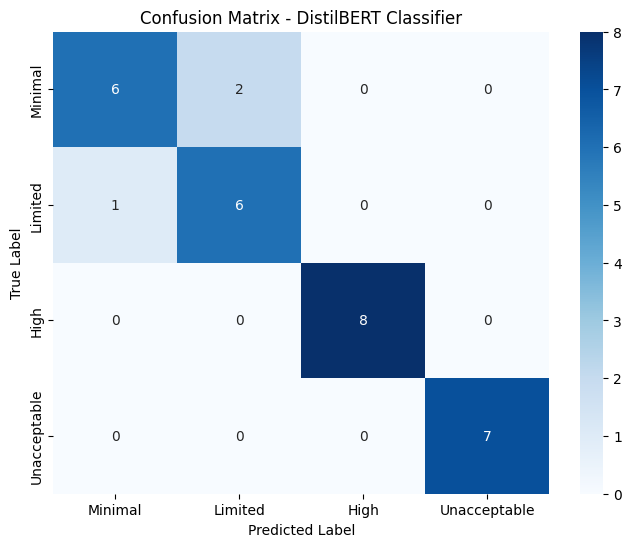

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from datasets import Dataset

save_path = "distilBERT_classifier"

model = AutoModelForSequenceClassification.from_pretrained(save_path)
tokenizer = AutoTokenizer.from_pretrained(save_path)

test_dataset = Dataset.from_pandas(test_df)
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

trainer = Trainer(model=model)

test_results = trainer.predict(tokenized_test)
logits = test_results.predictions
y_true = test_results.label_ids
y_pred = np.argmax(logits, axis=-1)

label_names = ["Minimal", "Limited", "High", "Unacceptable"]
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('Confusion Matrix - DistilBERT Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The evaluation of the fine-tuned DistilBERT model through the confusion matrix demonstrates exceptional classification performance. The results show a robust diagonal, indicating that the majority of the 30 test observations were correctly identified by the architecture. Notably, the model achieved 100% accuracy on the two most critical categories: High Risk and Unacceptable Risk, with zero misclassifications between these sensitive classes. Out of the total 30 samples, only three errors occurred (an overall accuracy of 90%), both involving the lower-tier categories of Minimal and Limited Risk. These minor discrepancies suggest that while the semantic boundaries between low-level risks are more nuanced, the model is highly reliable in distinguishing significant regulatory threats from minor ones.

## LEGAL-BERT Classifier

Legal-BERT is a transformer-based model specifically pre-trained on a massive corpus of legal text, including EU and UK legislation, court cases, and legal contracts. While standard models are trained on general data like Wikipedia or books, Legal-BERT was developed to master the highly structured and nuanced "legalese" found in official documents like the EU AI Act. Legal-BERT is a full-sized BERT model (110 mln parameters). While it requires more computational power than DistilBERT, it possesses a specialized vocabulary. It understands that words like "Article," "Recital," and "Provision" have specific legal weights that a general model might overlook.

In [ ]:
import pandas as pd
import os

file_path = "ai_risk_dataset.csv.txt"

if os.path.exists(file_path):
    print(f"Loading dataset from: {file_path}")
    df = pd.read_csv(file_path)

    print("\n--- FIRST 5 ROWS ---")
    print(df.head())

    print("\n--- LABEL DISTRIBUTION ---")
    print(df['label'].value_counts())
else:
    print(f"Error: '{file_path}' not found.")

Loading dataset from: ai_risk_dataset.csv.txt

--- FIRST 5 ROWS ---
                                                text              label
0  An AI-powered social scoring system used by mu...  Unacceptable_Risk
1  A real-time biometric identification system de...  Unacceptable_Risk
2  An AI application designed to subconsciously m...  Unacceptable_Risk
3  A predictive policing tool used to identify an...  Unacceptable_Risk
4  A cognitive-behavioral manipulation AI used by...  Unacceptable_Risk

--- LABEL DISTRIBUTION ---
label
Unacceptable_Risk    75
High_Risk            75
Limited_Risk         75
Minimal_Risk         75
Name: count, dtype: int64


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from scipy.special import softmax

label_map = {"Minimal_Risk": 0, "Limited_Risk": 1, "High_Risk": 2, "Unacceptable_Risk": 3}
df['label'] = df['label'].map(label_map)

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
eval_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

train_dataset = Dataset.from_pandas(train_df)
eval_dataset = Dataset.from_pandas(eval_df)
test_dataset = Dataset.from_pandas(test_df)


model_checkpoint = "nlpaueb/legal-bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)


tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_eval = eval_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=4)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    probabilities = softmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    recall = recall_score(labels, predictions, average='macro')
    auc = roc_auc_score(labels, probabilities, multi_class='ovr', average='macro')

    largest_class_count = max(np.bincount(labels))
    nir = largest_class_count / len(labels)

    return {
        "accuracy": accuracy,
        "f1_macro": f1,
        "recall_macro": recall,
        "roc_auc": auc,
        "NIR": nir
    }


training_args = TrainingArguments(
    output_dir="./legal_ai_risk_classifier",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=6,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    compute_metrics=compute_metrics,
)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were new

In [ ]:
import os

trainer.train()

print("\n--- TEST SET EVALUATION ---")
test_results = trainer.predict(tokenized_test)

if test_results.metrics:
    for key, value in test_results.metrics.items():
        print(f"  • {key}: {value:.4f}")

save_path = "legalBERT_classifier"


trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print(f"\n Training completed. Architecture and tokenizer saved locally to: {save_path}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Recall Macro,Roc Auc,Nir
1,1.370815,1.300663,0.400000,0.277174,0.406250,0.784347,0.266667
2,1.240285,1.002902,0.733333,0.725757,0.736607,0.955304,0.266667
3,0.912061,0.725229,0.800000,0.781944,0.794643,0.966006,0.266667
4,0.584639,0.592700,0.833333,0.809926,0.825893,0.972976,0.266667
5,0.438646,0.475157,0.933333,0.935417,0.937500,0.978429,0.266667
6,0.371792,0.464994,0.866667,0.856124,0.861607,0.982293,0.266667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


--- TEST SET EVALUATION ---


  • test_loss: 0.4634
  • test_accuracy: 0.8667
  • test_f1_macro: 0.8609
  • test_recall_macro: 0.8661
  • test_roc_auc: 0.9744
  • test_NIR: 0.2667
  • test_runtime: 1.1879
  • test_samples_per_second: 25.2540
  • test_steps_per_second: 3.3670


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Training completed. Architecture and tokenizer saved locally to: legalBERT_classifier


In [ ]:
log_history = trainer.state.log_history

metrics_per_epoch = {}

for entry in log_history:
    if "epoch" not in entry:
        continue

    epoch = round(entry["epoch"], 2)

    if epoch not in metrics_per_epoch:
        metrics_per_epoch[epoch] = {'Epoch': int(epoch)}

    if "loss" in entry and "eval_loss" not in entry:
        metrics_per_epoch[epoch]["Training Loss"] = entry["loss"]

    if "eval_loss" in entry:
        metrics_per_epoch[epoch]["Validation Loss"] = entry["eval_loss"]
        metrics_per_epoch[epoch]["Accuracy"] = entry.get("eval_accuracy")
        metrics_per_epoch[epoch]["F1 Macro"] = entry.get("eval_f1_macro")
        metrics_per_epoch[epoch]["Recall Macro"] = entry.get("eval_recall_macro")
        metrics_per_epoch[epoch]["Roc Auc"] = entry.get("eval_roc_auc")
        metrics_per_epoch[epoch]["Nir"] = entry.get("eval_NIR")

metrics_df = pd.DataFrame(list(metrics_per_epoch.values()))

metrics_df = metrics_df.dropna(subset=["Validation Loss"])

columns_order = [
    "Epoch", "Training Loss", "Validation Loss",
    "Accuracy", "F1 Macro", "Recall Macro", "Roc Auc", "Nir"
]
existing_columns = [col for col in columns_order if col in metrics_df.columns]
metrics_df = metrics_df[existing_columns]

print(metrics_df.to_string(index=False))

 Epoch  Training Loss  Validation Loss  Accuracy  F1 Macro  Recall Macro  Roc Auc      Nir
     1       1.370815         1.300663  0.400000  0.277174      0.406250 0.784347 0.266667
     2       1.240285         1.002902  0.733333  0.725757      0.736607 0.955304 0.266667
     3       0.912061         0.725229  0.800000  0.781944      0.794643 0.966006 0.266667
     4       0.584639         0.592700  0.833333  0.809926      0.825893 0.972976 0.266667
     5       0.438646         0.475157  0.933333  0.935417      0.937500 0.978429 0.266667
     6       0.371792         0.464994  0.866667  0.856124      0.861607 0.982293 0.266667


In [ ]:
log_history = trainer.state.log_history
data = []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        data.append({
            'Epoch': entry["epoch"],
            'Loss': entry["loss"],
            'Dataset': 'Training Loss'
        })


    if "eval_loss" in entry:
        data.append({
            'Epoch': entry["epoch"],
            'Loss': entry["eval_loss"],
            'Dataset': 'Validation Loss'
        })

df_base = pd.DataFrame(data)

if df_base[df_base['Dataset'] == 'Training Loss'].empty:
    print(" WARNING: No Training Loss data found in logs.")


all_frames = sorted(df_base['Epoch'].unique())
animated_data = []

for current_frame in all_frames:
    df_snapshot = df_base[df_base['Epoch'] <= current_frame].copy()
    df_snapshot['Frame'] = current_frame
    animated_data.append(df_snapshot)

df_animated = pd.concat(animated_data, ignore_index=True)


fig = px.line(
    df_animated,
    x="Epoch",
    y="Loss",
    color="Dataset",
    animation_frame="Frame",
    animation_group="Dataset",
    markers=True,
    title="Evolution of Training vs. Validation Loss",
    template="plotly_white",
    color_discrete_map={"Training Loss": "blue", "Validation Loss": "orange"},
    range_x=[0, df_base['Epoch'].max() * 1.05],
    range_y=[0, df_base['Loss'].max() * 1.1]
)

fig.show()

Performance report of LEGAL_BERT:

In [ ]:
print(f"Accuracy: {test_results.metrics['test_accuracy'] * 100:.2f}%")
print(f"F1 Score: {test_results.metrics['test_f1_macro']:.4f}")
print(f"Recall:   {test_results.metrics['test_recall_macro']:.4f}")
print(f"ROC AUC:  {test_results.metrics['test_roc_auc']:.4f}")
print(f"NIR:      {test_results.metrics['test_NIR'] * 100:.2f}%")

Accuracy: 86.67%
F1 Score: 0.8609
Recall:   0.8661
ROC AUC:  0.9744
NIR:      26.67%


Based on the empirical results, DistilBERT is the recommended model so far for the EU AI Act risk classification task. While Legal-BERT offers specialized pre-training on legal corpora, the data used in this classification task contains highly distinct linguistic markers, such as "social scoring" for Unacceptable Risk or "critical infrastructure" for High-Risk, which provide a clear signal that even a distilled model can capture with high precision. Because both models reached a performance ceiling with nearly identical metrics, the Occam’s Razor principle applies: the simplest solution is the best. DistilBERT provides the same level of legal accuracy as its larger counterpart while offering a 40% reduction in size, making it the superior choice for a scalable, cost effective deployment.

# RNN (GRU BASED)

Recurrent Neural Networks, or **RNNs**, are specialized neural architectures designed to process sequential data where the order of information is critical, such as music, trajectories, text, and time series. Unlike traditional feed-forward neural networks where all inputs and outputs are independent of each other, RNNs operate on the principle that previous steps in a sequence are required to inform the current step. The primary goal and purpose of this architecture is to provide the network with a form of memory, allowing it to remember previous words or data points to better understand and predict subsequent elements in a sequence.

The architecture is characterized by the introduction of a *hidden state*, often referred to as a memory state, which captures and retains information about the sequence as it is processed. In a recurrent neuron, the output of a step is sent back into the neuron as an input for the next step, meaning the neuron has at least two inputs: the new data point and its own previous output. To simplify the model and reduce parameter complexity, RNNs perform the same task on every element of the sequence by using the same *shared parameters* for each input at every timestep. This process is often visualized by unrolling the network, where the activation and output for each specific timestep are computed using weight matrices and activation functions like sigmoid or hyperbolic tangent.

The design of RNNs allows for several versatile configurations depending on the task, such as many-to-one structures for sentiment analysis, many-to-many for machine translation or entity extraction, and one-to-many for tasks like music generation. One of the main advantages of this architecture is its ability to process input sequences of any length without the model size increasing proportionally to the input. However, these networks face significant drawbacks, including slow computation speeds and the difficulty of accessing information from a long time ago in the sequence. Furthermore, a standard RNN cannot consider future inputs for its current state, and it often begins to forget the earliest inputs as information is lost during each step of the process.

Below there's the code used to download and prepare **GloVe** (Global Vectors for Word Representation), a library developed by Stanford researchers that converts words into dense vectors that capture semantic relationships and context based on global word co-occurrence statistics. These pre-trained embeddings provide models with a mathematical "memory" of word meanings, significantly improving performance in tasks like sentiment analysis and translation.

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2026-03-26 14:32:36--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-26 14:32:36--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-26 14:32:36--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

The process begins with dataset cleaning and normalization, where hyphens are removed from the text and risk categories are mapped to numerical values (0–3) to be processed by the neural network. The data is then split into training, evaluation, and test sets as in the previus distilbert and legalbert model to ensure consistency for the following performance comparison. Subsequently, the text is transformed into sequences of integers through a vectorization step, using a limited vocabulary and a fixed sequence length, preparing the inputs for neural network models such as a many-to-one RNN architecture.

In [ ]:
import pandas as pd
import os

file_path = "ai_risk_dataset.csv.txt"

if os.path.exists(file_path):
    print(f"Loading dataset from: {file_path}")
    df = pd.read_csv(file_path)
else:
    print(f"Error: '{file_path}' not found.")

Loading dataset from: ai_risk_dataset.csv.txt


In [ ]:
df = pd.read_csv(file_path)
df['text'] = df['text'].str.replace('-', ' ', regex=False)

label_map = {"Minimal_Risk": 0, "Limited_Risk": 1, "High_Risk": 2, "Unacceptable_Risk": 3}
df['label'] = df['label'].map(label_map)

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
eval_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])


X_train, y_train = train_df['text'].to_numpy(), train_df['label'].to_numpy()
X_eval, y_eval = eval_df['text'].to_numpy(), eval_df['label'].to_numpy()
X_test, y_test = test_df['text'].to_numpy(), test_df['label'].to_numpy()

Then, the pre-trained GloVe embeddings are loaded from a file, where each word is associated with a numerical vector, and all these pairs are stored in a dictionary for easy lookup. This creates a reference structure that can be used later to retrieve semantic representations of words.

In [ ]:
embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32') # embddings
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} pre-trained word vectors.")

Found 400000 pre-trained word vectors.


Below, the training text is processed using a text vectorization step, which converts sentences into sequences of integers based on a limited vocabulary and a fixed sequence length. At the same time, a mapping between each word and its corresponding index is created, allowing the model to consistently refer to each token. Once this is done, an embedding matrix is initialized with zeros. The code then iterates over every word in the vocabulary and tries to find its corresponding GloVe vector in the previously built dictionary. When a match is found, the vector is inserted into the correct position in the matrix; otherwise, the word remains represented by a zero vector. In this way, the embedding matrix gradually becomes a bridge between the dataset vocabulary and the pre-trained semantic information provided by GloVe. Finally, the code prints how many words were successfully matched with existing embeddings and how many were missing, giving an idea of how much of the vocabulary is covered.

In [ ]:
from tensorflow.keras.layers import TextVectorization
max_features = 1500
sequence_length = 100

vectorizer = TextVectorization(
    max_tokens=max_features,
    output_sequence_length=sequence_length
)

vectorizer.adapt(X_train)

voc = vectorizer.get_vocabulary()
word_index = dict(zip(voc, range(len(voc))))
num_tokens = len(voc)
embedding_dim = 100 #  match the GloVe file downloaded (100d)

embedding_matrix = np.zeros((num_tokens, embedding_dim))

hits = 0
misses = 0
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1

print(f"Converted {hits} words ({misses} misses)")

Converted 1486 words (8 misses)


The netx code performs an integrity check to identify Out-of-Vocabulary (OOV) words by comparing your dataset's unique tokens against the GloVe database. Any terms found in your AI risk text that are missing from the Stanford dictionary are collected into a separate list for diagnostic purposes. This step is crucial because words without an embedding cannot leverage the "memory" or historical context provided by pre-trained weights, which is a key advantage of RNN architectures.

In [ ]:
missing_words = []

for word in word_index.keys():
    if word not in embeddings_index:
        missing_words.append(word)

print("missing words:", missing_words)

missing words: ['', '[UNK]', np.str_('chatbot'), np.str_('deepfake'), np.str_('neurodivergent'), np.str_('librarys'), np.str_('gamified'), np.str_('deprioritizes')]


Finally, the architecture of the neural network and the optimization strategy are defined to classify AI risk, combining sequential memory mechanisms with advanced techniques to improve accuracy and reduce overfitting.

The model follows a **Sequential, many-to-one (sequence-to-vector) architecture**.

In the first stage, the input text is processed through a *vectorization layer*, which converts raw text into sequences of numerical indices. These sequences are then passed to an *Embedding layer*, which uses the pre-trained GloVe embedding matrix. (By setting trainable=False, the model leverages existing linguistic knowledge without modifying the learned representations.)

To improve generalization, a *SpatialDropout1D layer* is applied, randomly dropping entire embedding channels and preventing the network from relying too heavily on specific words. The core of the model is a *Bidirectional GRU* (Gated Recurrent Unit), which captures contextual dependencies in both forward and backward directions. Thanks to its gating mechanism, the GRU is able to effectively manage long-term dependencies while maintaining computational efficiency.

In the end, the extracted representation is passed through *Dense layers*, which perform the actual classification. The output layer consists of 4 neurons with a softmax activation function, producing probability distributions over the four AI risk classes: Minimal, Limited, High, and Unacceptable.

The training strategy is define as follows:  

*   *PolynomialDecay learning rate* scheduler gradually reduces the learning rate from 10^(-3)to 10^(-5), allowing more stable convergence during later training stages.
*   *AdamW optimizer* is used to combine adaptive learning with weight decay regularization, helping to control model complexity and prevent overfitting.
* *Sparse categorical crossentropy* loss function is employed, as the target labels are encoded as integer values rather than one-hot vectors.









In [ ]:
from tensorflow.keras.layers import SpatialDropout1D
model = Sequential([
    Input(shape=(1,), dtype=tf.string),
    vectorizer,

    Embedding(
        input_dim=num_tokens,
        output_dim=embedding_dim,
        embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
        trainable=False,
    ),

    SpatialDropout1D(0.2),

    Bidirectional(
        GRU(
            32,
            dropout=0.2,
            recurrent_dropout=0.1,
            return_sequences=False
        )
    ),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(4, activation='softmax')
])


total_steps = (len(X_train) // 8) * 10 # epochs = 10

# linear decay
lr_scheduler = PolynomialDecay(
    initial_learning_rate=1e-3,
    end_learning_rate=1e-5,
    decay_steps=total_steps,
    power=1.0
)


model.compile(
    optimizer=AdamW(learning_rate=lr_scheduler, weight_decay=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

The next code represents the final training phase, where the model learns to classify AI risk from the dataset. *Early stopping* is used to prevent overfitting by monitoring validation loss and stopping training if it does not improve, while restoring the best weights. The *model.fit()* process trains the model on the training data, evaluates it on validation data after each epoch, and updates weights over multiple epochs and small batches.

At the end, the model learns meaningful patterns by *combining GRU-based sequential memory with GloVe embeddings*, and the training history stores performance metrics such as loss and accuracy.

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_eval, y_eval),
    epochs=10,
    batch_size=8,
    callbacks=callbacks
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.3208 - loss: 1.3789 - val_accuracy: 0.4667 - val_loss: 1.3501
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.3083 - loss: 1.3645 - val_accuracy: 0.3333 - val_loss: 1.3510
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.3125 - loss: 1.3767 - val_accuracy: 0.3667 - val_loss: 1.3372
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.3333 - loss: 1.3590 - val_accuracy: 0.2667 - val_loss: 1.3296
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.4083 - loss: 1.3246 - val_accuracy: 0.4333 - val_loss: 1.3129
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.4000 - loss: 1.3281 - val_accuracy: 0.3667 - val_loss: 1.2934
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.3958 - loss: 1.3109 - val_accuracy: 0.5000 - val_loss: 1.2773
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.3792 - loss: 1.2912 - val_accuracy: 0.4667 - val_los

In [ ]:
metrics_dict = history.history
metrics_df = pd.DataFrame(metrics_dict)
metrics_df.insert(0, 'Epoch', range(1, len(metrics_df) + 1))
print(metrics_df.to_string(index=False))

 Epoch  accuracy     loss  val_accuracy  val_loss
     1  0.320833 1.378923      0.466667  1.350081
     2  0.308333 1.364484      0.333333  1.350978
     3  0.312500 1.376738      0.366667  1.337161
     4  0.333333 1.358967      0.266667  1.329648
     5  0.408333 1.324602      0.433333  1.312861
     6  0.400000 1.328061      0.366667  1.293407
     7  0.395833 1.310919      0.500000  1.277326
     8  0.379167 1.291183      0.466667  1.263833
     9  0.475000 1.263266      0.433333  1.256713
    10  0.433333 1.273312      0.433333  1.254900


The training process is visualized through this animated graph that shows the evolution of both training and validation loss over time. The loss values are extracted from the history object returned by model.fit(), and then organized into a structured format.

For each epoch, the graph progressively displays how the model’s performance changes, allowing a direct comparison between training loss and validation loss. This makes it easier to observe whether the model is learning effectively and to detect possible overfitting.

The animation highlights how the losses decrease (or stabilize) across epochs, providing an intuitive representation of the training dynamics of the GRU model.

In [ ]:
# The model.fit() process in Keras returns a history object.
# extract the training and validation losses from it:
train_loss = history.history['loss']
eval_loss = history.history['val_loss']

# Keras epochs are 0-indexed
epochs = [e + 1 for e in history.epoch]

data = []

for e, l in zip(epochs, train_loss):
    data.append({'Epoch': e, 'Loss': l, 'Dataset': 'Training Loss'})
for e, l in zip(epochs, eval_loss):
    data.append({'Epoch': e, 'Loss': l, 'Dataset': 'Validation Loss'})

df_base = pd.DataFrame(data)

animated_data = []
unique_epochs = sorted(list(set(epochs)))


for current_frame in unique_epochs:
    df_snapshot = df_base[df_base['Epoch'] <= current_frame].copy()
    df_snapshot['Frame'] = current_frame
    animated_data.append(df_snapshot)

df_animated = pd.concat(animated_data, ignore_index=True)

fig = px.line(
    df_animated,
    x="Epoch",
    y="Loss",
    color="Dataset",
    animation_frame="Frame",
    animation_group="Dataset",
    markers=True,
    range_x=[0, df_base['Epoch'].max() + 0.2],
    range_y=[df_base['Loss'].min() * 0.9, df_base['Loss'].max() * 1.1],
    title="Evolution of Training vs. Validation Loss (GRU Model)",
    template="plotly_white",
    color_discrete_map={"Training Loss": "blue", "Validation Loss": "orange"}
)

fig.show()

At the end, we perform the final evaluation stage, where the model is tested on unseen data to assess how well it generalizes beyond the training phase. The model first produces probability scores for each class and then converts them into final predictions by selecting the class with the highest probability.

To evaluate performance, several metrics are computed, including accuracy, F1-score, recall, and ROC AUC, providing a comprehensive view of how well the model classifies and distinguishes between the different risk levels.

In addition, the Near Information Rate (NIR) is calculated as a baseline, representing the accuracy that would be achieved by always predicting the most frequent class. This helps determine whether the model is truly learning meaningful patterns or simply relying on class distribution.

In [ ]:
probabilities = model.predict(X_test)
predictions = np.argmax(probabilities, axis=-1)

accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average='macro')
recall = recall_score(y_test, predictions, average='macro')
auc = roc_auc_score(y_test, probabilities, multi_class='ovr', average='macro')

largest_class_count = max(np.bincount(y_test))
nir = largest_class_count / len(y_test)

results = {
    "accuracy": accuracy,
    "f1_macro": f1,
    "recall_macro": recall,
    "roc_auc": auc,
    "NIR": nir
}

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [ ]:
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

accuracy: 0.7000
f1_macro: 0.6961
recall_macro: 0.6920
roc_auc: 0.9328
NIR: 0.2667


# ULMFIT CLASSIFIER

**ULMFiT** (Universal Language Model Fine-tuning) is a transfer learning approach designed for natural language processing tasks, particularly text classification. Unlike traditional models trained from scratch, ULMFiT leverages a pre-trained language model that has already learned general linguistic patterns from large text corpora, and then adapts it to a specific task. This allows the model to achieve strong performance even with relatively small labeled datasets.

The process is divided into three distinct stages that progressively specialize a neural network for a specific task:

* In the first phase, a large-scale architecture, typically an AWD-LSTM, is trained on a massive, general-purpose corpus like Wikipedia to learn the fundamental structures, grammar, and semantics of a language.

* The second phase, known as *Domain Adaptation*, refines the pre-trained model on the specific dataset related to the final task, such as technical or legal documents like the AI Act. This step allows the network to adapt its internal "memory" to the unique vocabulary, jargon, and stylistic nuances of the target domain.

* In the final phase, the language model is converted into a classifier by replacing the word-prediction head with new layers and a softmax function to predict specific categories, such as AI risk levels. To preserve the deep knowledge gained previously, it employs sophisticated techniques like gradual unfreezing and discriminative learning rates, preventing the model from forgetting its linguistic foundation while it masters the specialized classification task.

In terms of architecture, ULMFiT typically relies on *LSTM-based networks*, which are well-suited for handling sequential data and maintaining contextual information over time. This enables the model to effectively capture long-range dependencies in text, addressing some of the limitations of basic RNNs.

One of the key strengths of ULMFiT lies in its ability to generalize across different NLP tasks with minimal adjustments, significantly reducing training time and improving performance. However, it may require careful fine-tuning and hyperparameter selection to achieve optimal results, especially when dealing with highly domain-specific data.

The process begins with dataset cleaning and normalization, where hyphens are removed from the text and risk categories are mapped to numerical values (0–3) to be processed by the neural network. The data is then split into training, evaluation, and test sets as in the previus distilbert, legalbert and RNN model to ensure consistency for the following performance comparison.

In [ ]:
file_path = "ai_risk_dataset.csv.txt"

df = pd.read_csv(file_path)
df['text'] = df['text'].str.replace('-', ' ', regex=False)

label_map = {"Minimal_Risk": 0, "Limited_Risk": 1, "High_Risk": 2, "Unacceptable_Risk": 3}
df['label'] = df['label'].map(label_map)

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
eval_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

This stage implements the second step of the Universal Language Model Fine-tuning (ULMFiT) architecture called domain Adaptation. We initialize an AWD-LSTM (ASGD Weight-Dropped LSTM) model pre-trained on the WikiText-103 dataset. We then feed it the raw text of the EU AI Act without any classification labels (is_lm=True). The model is trained using a next-word prediction objective.

The pre-trained Wikipedia model understands general English grammar and syntax, but it lacks knowledge of specific legal and technical terms.

With only 300 labeled examples for the final classifier, training from scratch would lead to poor performance, since is well known that lstm models need large datasets.

Slanted Triangular Learning Rates (STLR): The fit_one_cycle method dictates that the learning rate quickly increases to a peak and then slowly decays. This allows the model to rapidly traverse the loss landscape to find a good optimal region, then fine-tune its weights precisely.

The first phase of ULMFiT, the general language model pretraining, is already implicit here because we are using a pre-trained AWD-LSTM model trained on WikiText-103. This step is skipped in practice since training a language model from scratch requires massive datasets and computational resources, and pre-trained models already capture general English grammar and syntax.

At this stage, we are performing the **domain adaptation** step of ULMFiT. We fine-tune the pre-trained model on the raw text of the EU AI Act. Using a TextDataLoader with is_lm=True, the model learns to predict the next word in a sequence, adapting its knowledge to the legal and technical vocabulary of the domain without any classification labels.

The pre-trained Wikipedia model already understands general English grammar and syntax, but it does not know the specific legal and technical terms used in the EU AI Act. By fine-tuning on this domain-specific text, the model learns the specialized vocabulary and phrasing that it would not encounter in a general corpus.

This step is also crucial because we only have a limited number of labeled examples (around 300) for the final classifier. Training an LSTM from scratch on such a small dataset would lead to poor performance, since LSTM models are known to require large amounts of data. By fine-tuning a pre-trained model, we transfer general linguistic knowledge to our domain, enabling the model to perform well even with few labeled examples.

During training, Slanted Triangular Learning Rates (STLR) are applied via FastAI’s fit_one_cycle method. The learning rate quickly rises to explore the loss landscape and then decays gradually, allowing the model to fine-tune its weights precisely.

In [ ]:
import pandas as pd
from fastai.text.all import *

# extract raw text
ai_act_texts = [doc.page_content for doc in polished_documents]
df_lm = pd.DataFrame({'text': ai_act_texts})

# is_lm=True tells fastai to set up the data for predicting the next word
dls_lm = TextDataLoaders.from_df(df_lm, text_col='text', is_lm=True, valid_pct=0.1)

print(f"Vocab size: {len(dls_lm.vocab)}")

Vocab size: 2288


language_model_learner() function automatically creates a pytorch model for next word prediction.


AWD-LSTM uses multiple different types of dropout simultaneously (dropping out random words, dropping out connections between RNN layers and more)

drop_mult=0.3 --> lowering the amount of dropout to $30\%$ of the default, to avoid throwing away too much of its pre-trained knowledge.

This block initializes and fine-tunes the language model for our domain-specific text. The language_model_learner() function creates a PyTorch AWD-LSTM model configured for next-word prediction, which is ideal for capturing sequential patterns and long-range dependencies in text.

AWD-LSTM applies multiple forms of dropout simultaneously, including dropping random words in a sequence and zeroing connections between RNN layers, which helps prevent overfitting. The drop_mult=0.3 argument scales the dropout to 30% of the default, reducing the risk of discarding too much of the model’s pre-trained knowledge from WikiText-103 while still keeping some regularization.

Training is done in two stages: first, only the new head is trained for 1 epoch with a higher learning rate to quickly adapt to the domain, then the entire model is unfrozen and fine-tuned for 4 epochs at a smaller learning rate, allowing all weights to adjust carefully to the AI Act text.

Finally, the encoder is saved with learn_lm.save_encoder(), so it can be reused for the classifier fine-tuning stage, transferring the knowledge learned in this domain-specific language modeling step.

In [ ]:
# initialize the Language Model, wiki weight automaticallty downloaded
learn_lm = language_model_learner(dls_lm, AWD_LSTM, drop_mult=0.3, metrics=[accuracy, Perplexity()]) # perplexity to monitor (=exp(loss))


# fit_one_cycle applies Slanted Triangular Learning Rates
learn_lm.fit_one_cycle(1, 2e-2) # Train only the head with high learning rate for 1 epoch
learn_lm.unfreeze() # unlock the whole model
learn_lm.fit_one_cycle(4, 2e-3) # Train the whole model on AI Act for 4 epochs


learn_lm.save_encoder('finetuned_ai_act_encoder')
print("Language Model fine-tuned and encoder saved")

<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:02&lt;00:00]</div>

epoch,train_loss,valid_loss,accuracy,perplexity,time
0,3.392025,2.978918,0.406161,19.666533,00:09


epoch,train_loss,valid_loss,accuracy,perplexity,time
0,2.672191,2.651366,0.451483,14.173383,00:11
1,2.425182,2.398654,0.499957,11.008347,00:09
2,2.171520,2.317138,0.512923,10.146590,00:09
3,1.945796,2.309825,0.516548,10.072661,00:11


Language Model fine-tuned and encoder saved


This is the core classification phase. We construct a new TextDataLoaders object for the classification task. We pass text_vocab=dls_lm.vocab to synchronize the vocabulary mapping. We then load the customized "encoder"  and attach a new, randomly initialized classification head for the 4 risk categories. Training is conducted via Gradual Unfreezing and Discriminative Learning Rates.


Instead of training all layers at once, layers are unfrozen one by one starting from the top (the classification head) down to the bottom (the embeddings).


In the code slice(1e-3/(2.6**4), 1e-3), different layers of the network receive different learning rates. The deepest layers capture fundamental language rules and require very small updates. The final layers capture task-specific features and require larger updates. The denominator 2.6**4 is an empirical heuristic proven in the ULMFiT paper to be optimal for scaling learning rates across AWD-LSTM layers.


training and validation losses across multiple discrete training phases are captured and stitched into dataframe.
Because fastai's fit_one_cycle method resets the internal recorder after every cycle, relying on a single final history extraction only yields the final phase's metrics. Manually extending lists (all_train_losses.extend(...)) after every freeze/unfreeze state guarantees the extraction of the metrics across all epochs.

Instead of treating the AWD-LSTM as thousands of individual, separate neural layers, fastai bundles them into Layer Groups.

Group 1 (Bottom): Word Embeddings (understanding basic vocabulary).

Group 2 (Middle): Lower LSTM layers (understanding basic grammar).

Group 3 (Higher): Upper LSTM layers (understanding complex AI Act context).

Group 4 (Top): The Classification Head

This block implements the core classification phase of ULMFiT. We first construct a new *TextDataLoaders* object for the classification task, passing text_vocab=dls_lm.vocab to ensure the classifier uses the same vocabulary as the fine-tuned language model. The encoder learned during domain adaptation (finetuned_ai_act_encoder) is then loaded and connected to a new randomly initialized classification head, which will predict the 4 AI risk categories.

Training is performed using *Gradual Unfreezing* and *Discriminative Learning Rates*, two key techniques in ULMFiT: instead of updating all layers at once, we gradually unfreeze the network from the top (the classification head) to the bottom (the embedding layer), fine-tuning each layer group appropriately.

The slice() notation assigns different learning rates to different layer groups: the deepest layers, which encode fundamental language patterns, get very small updates, while the final layers, responsible for task-specific features, receive larger updates. The factor 2.64 is an empirical heuristic from the ULMFiT paper that works well for scaling learning rates across AWD-LSTM layers.

FastAI organizes the AWD-LSTM into four Layer Groups:

* Group 1 (Bottom): Word embeddings, capturing basic vocabulary knowledge.
* Group 2 (Middle): Lower LSTM layers, learning grammar and simple structures.
* Group 3 (Higher): Upper LSTM layers, encoding more complex context relevant to the AI Act.
* Group 4 (Top): Classification head, mapping learned features to the 4 risk classes.

Because fit_one_cycle resets its internal recorder after each training call, we manually collect training and validation losses across all phases (all_train_losses and all_valid_losses). This ensures we have a complete record of model performance over all epochs, across multiple freeze/unfreeze stages.

Overall, this approach allows the model to preserve pre-trained knowledge from the language model, while gradually adapting to the classification task, making the most of the small labeled dataset and improving generalization.

In [ ]:
import pandas as pd

#  row marked as false for trainign and true for validation
train_df['is_valid'] = False
eval_df['is_valid'] = True
df_class = pd.concat([train_df, eval_df])

dls_clas = TextDataLoaders.from_df(
    df_class,
    text_col='text',
    label_col='label',
    valid_col='is_valid',
    text_vocab=dls_lm.vocab, # vocab from LM
    bs=16
)

# Initialize Classifier and load the encoder
learn_clas = text_classifier_learner(dls_clas, AWD_LSTM, drop_mult=0.5, metrics=accuracy)
learn_clas = learn_clas.load_encoder('finetuned_ai_act_encoder')

# store the history
all_train_losses = []
all_valid_losses = []

# Train Head
learn_clas.fit_one_cycle(1, 2e-2) # here group 1 2 3 are locked
all_train_losses.extend([val[0] for val in learn_clas.recorder.values])
all_valid_losses.extend([val[1] for val in learn_clas.recorder.values])


learn_clas.freeze_to(-2) # freeze everything but the last 2 groups
learn_clas.fit_one_cycle(1, slice(1e-2/(2.6**4), 1e-2)) # final learning rate = 1e-2 assigned to the head, initial lr is 1e-2/(2.6**4 assigned to the bottom layer
all_train_losses.extend([val[0] for val in learn_clas.recorder.values])
all_valid_losses.extend([val[1] for val in learn_clas.recorder.values])

learn_clas.freeze_to(-3)
learn_clas.fit_one_cycle(1, slice(5e-3/(2.6**4), 5e-3))
all_train_losses.extend([val[0] for val in learn_clas.recorder.values])
all_valid_losses.extend([val[1] for val in learn_clas.recorder.values])

#  unfreeze whole model
learn_clas.unfreeze()
learn_clas.fit_one_cycle(3, slice(1e-3/(2.6**4), 1e-3))
all_train_losses.extend([val[0] for val in learn_clas.recorder.values])
all_valid_losses.extend([val[1] for val in learn_clas.recorder.values])

epoch,train_loss,valid_loss,accuracy,time
0,1.237518,1.167198,0.566667,00:04


epoch,train_loss,valid_loss,accuracy,time
0,0.968733,1.098085,0.600000,00:04


epoch,train_loss,valid_loss,accuracy,time
0,0.737918,0.835372,0.633333,00:02


epoch,train_loss,valid_loss,accuracy,time
0,0.535898,0.773736,0.700000,00:04
1,0.494404,0.740104,0.700000,00:04
2,0.473397,0.725436,0.700000,00:03


In the next block, we visualize the training process of the ULMFiT classifier. Using the recorded training and validation losses collected across all epochs and all freeze/unfreeze phases, we create a dataframe that tracks loss values for every epoch.

We then generate an animated line chart with *Plotly*, showing how both the training and validation loss evolve over time. Each frame corresponds to a specific epoch, allowing us to see how the model gradually learns and adapts its weights during the different stages of fine-tuning.

This visualization makes it easy to observe convergence, potential overfitting, and the overall dynamics of the model’s learning process across the entire training schedule.

In [ ]:
epochs = [e + 1 for e in range(len(all_train_losses))]

data = []

for e, t_loss, v_loss in zip(epochs, all_train_losses, all_valid_losses):
    data.append({'Epoch': e, 'Loss': t_loss, 'Dataset': 'Training Loss'})
    data.append({'Epoch': e, 'Loss': v_loss, 'Dataset': 'Validation Loss'})

df_base = pd.DataFrame(data)

animated_data = []
unique_epochs = sorted(list(set(epochs)))

for current_frame in unique_epochs:
    df_snapshot = df_base[df_base['Epoch'] <= current_frame].copy()
    df_snapshot['Frame'] = current_frame
    animated_data.append(df_snapshot)

df_animated = pd.concat(animated_data, ignore_index=True)

fig = px.line(
    df_animated,
    x="Epoch",
    y="Loss",
    color="Dataset",
    animation_frame="Frame",
    animation_group="Dataset",
    markers=True,
    range_x=[0.5, df_base['Epoch'].max() + 0.5],
    range_y=[df_base['Loss'].min() * 0.9, df_base['Loss'].max() * 1.1],
    title="Evolution of Training vs. Validation Loss (ULMFiT Model)",
    template="plotly_white",
    color_discrete_map={"Training Loss": "blue", "Validation Loss": "orange"}
)

fig.show()

At the end, we perform the final evaluation of the ULMFiT classifier on the test set, which contains data the model has never seen during training or validation.

We first create a test dataloader from the test dataframe, then use learn_clas.get_preds() to generate the predicted probabilities for each class as well as the true labels. The probabilities are converted to NumPy arrays, and the predicted class for each example is determined using argmax. Next, we compute some standard classification metrics to assess the model’s performance: Accuracy, F1 score, Recall.
We also calculate the Near Information Rate (NIR), which represents the accuracy that would be obtained by always predicting the most frequent class. This acts as a baseline: if the model’s accuracy is close to the NIR, it indicates that the classifier is not learning meaningful patterns from the data.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score
import numpy as np

# dataloader for the test
dl_test = learn_clas.dls.test_dl(test_df, with_labels=True)
probabilities, y_test_fastai = learn_clas.get_preds(dl=dl_test)

probs_np = probabilities.numpy()
preds_np = np.argmax(probs_np, axis=-1)
y_true_np = y_test_fastai.numpy()

accuracy = accuracy_score(y_true_np, preds_np)
f1 = f1_score(y_true_np, preds_np, average='macro')
recall = recall_score(y_true_np, preds_np, average='macro')

try:
    auc = roc_auc_score(y_true_np, probs_np, multi_class='ovr', average='macro')
except ValueError:
    auc = "N/A"

largest_class_count = max(np.bincount(y_true_np))
nir = largest_class_count / len(y_true_np)

results = {
    "accuracy": accuracy,
    "f1_macro": f1,
    "recall_macro": recall,
    "roc_auc": auc,
    "NIR": nir
}

for metric, value in results.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")

accuracy: 0.8667
f1_macro: 0.8609
recall_macro: 0.8616
roc_auc: 0.9816
NIR: 0.2667


In [ ]:
learn_clas.export('ulmfit_ai_risk_classifier.pkl')

# RANDOM FOREST CLASSIFIER

**Random Forest** is an ensemble learning method used for classification and regression that operates by constructing a multitude of decision trees during training. Instead of relying on a single complex tree, which might overfit the data, Random Forest creates a "forest" of diverse trees and merges their results—typically through a majority vote—to achieve a more accurate and stable prediction. This approach is particularly effective for sequential data like text because it can handle high-dimensional features while maintaining high performance across different segments of the dataset.

The code implements a complete machine learning pipeline for text classification, shifting from the deep learning approach of RNNs to a robust ensemble method. The code begins by loading the AI risk dataset and performing a stratified split to ensure that the distribution of risk labels remains consistent across the training (80%), evaluation (10%), and testing (10%) sets. Then, it defines a Pipeline that sequentially applies two main steps: a *TfidfVectorizer* to convert raw text into numerical features based on word importance and a *RandomForestClassifier* configured with balanced class weights to handle any potential disparities in the dataset's labels.

Through *GridSearchCV*, the script systematically explores a grid of parameters, such as the number of trees (n_estimators), their maximum depth (max_depth), and the number of features considered for each split (max_features). This process uses 5-fold cross-validation to find the combination that yields the highest F1-macro score. Once the best parameters are identified, the model is trained on the full training set and evaluated on the held-out test data.

The output of this code provides a comprehensive view of the model's effectiveness. By printing the Best Parameters, the script reveals the optimal complexity required for the random forest to classify AI risks accurately. The Best Cross-Validation F1-Macro score serves as a reliable estimate of how well the model generalizes to unseen data. Finally, the classification_report breaks down performance by individual risk category, providing precision, recall, and F1-scores.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import pandas as pd

file_path = "ai_risk_dataset.csv.txt"
df = pd.read_csv(file_path)

X_train, X_temp, y_train, y_temp = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

X_eval, X_test, y_eval, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1500, stop_words='english')),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],

    'classifier__max_depth': [10, 20, 30, None],

    'classifier__max_features': ['sqrt', 'log2', 0.15, 0.2]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\n=== Grid Search Complete ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Macro: {grid_search.best_score_:.4f}\n")

best_rf_model = grid_search.best_estimator_
predictions = best_rf_model.predict(X_test)

print("=== Best Model Performance on Test Set ===")
print(classification_report(y_test, predictions))


=== Grid Search Complete ===
Best Parameters: {'classifier__max_depth': 20, 'classifier__max_features': 'log2', 'classifier__n_estimators': 100}
Best Cross-Validation F1-Macro: 0.7475

=== Best Model Performance on Test Set ===
                   precision    recall  f1-score   support

        High_Risk       1.00      0.38      0.55         8
     Limited_Risk       0.83      0.71      0.77         7
     Minimal_Risk       0.44      0.88      0.58         8
Unacceptable_Risk       0.80      0.57      0.67         7

         accuracy                           0.63        30
        macro avg       0.77      0.63      0.64        30
     weighted avg       0.76      0.63      0.64        30



# SVM CLASSIFIER

**Support Vector Machine** (SVM) is a sophisticated supervised learning algorithm designed to find the optimal hyperplane that maximizes the margin between different classes in a high-dimensional space. Unlike deep learning architectures like RNNs that process data as a sequence to maintain a memory state , SVM treats text as a collection of features, making it highly efficient for document classification tasks where the number of features often exceeds the number of samples. By focusing only on the support vectors—the data points closest to the decision boundary—SVM achieves a robust classification that generalizes well to unseen data.

The code implements this logic through a structured Pipeline that begins by loading the AI risk dataset and splitting it into training, evaluation, and test sets using stratification to maintain balanced risk labels. The first step uses a *TfidfVectorizer* to convert raw text into numerical values, weighing the importance of specific words within the context of the entire dataset. This is followed by a *Linear Support Vector Classifier* (SVC) configured with a linear kernel and balanced class weights, which is particularly effective for high-dimensional sparse data like text embeddings.

To ensure the highest possible performance, the script utilizes *GridSearchCV* to test various combinations of hyperparameters, such as the regularization parameter C—which controls the trade-off between margin maximization and classification error—and different vocabulary sizes or n-gram ranges. Through 5-fold cross-validation, the process identifies the configuration that yields the best F1-macro score, a metric that treats all risk categories with equal importance. Once the optimal model is identified, it is evaluated on the final test set to produce a classification report, providing a clear and reliable assessment of how well the SVM can distinguish between different levels of AI risk.

In [ ]:
file_path = "ai_risk_dataset.csv.txt"
df = pd.read_csv(file_path)


X_train, X_temp, y_train, y_temp = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

X_eval, X_test, y_eval, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('classifier', SVC(kernel='linear', class_weight='balanced', random_state=42, probability = True))
])

param_grid = {
    # different levels of strictness for the SVM
    'classifier__C': [0.1, 1, 10, 100],

    # different vocabulary sizes
    'tfidf__max_features': [1000, 1500, 2000],

    # Unigrams (1,1) vs Unigrams + Bigrams (1,2)
    'tfidf__ngram_range': [(1, 1), (1, 2)]
}

grid_search_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train, y_train)

print("\n=== SVM Grid Search Complete ===")
print(f"Best Parameters: {grid_search_svm.best_params_}")
print(f"Best Cross-Validation F1-Macro: {grid_search_svm.best_score_:.4f}\n")

best_svm_model = grid_search_svm.best_estimator_
predictions = best_svm_model.predict(X_test)

print("=== Best SVM Model Performance on Test Set ===")
print(classification_report(y_test, predictions))

Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== SVM Grid Search Complete ===
Best Parameters: {'classifier__C': 10, 'tfidf__max_features': 1500, 'tfidf__ngram_range': (1, 1)}
Best Cross-Validation F1-Macro: 0.8787

=== Best SVM Model Performance on Test Set ===
                   precision    recall  f1-score   support

        High_Risk       0.86      0.75      0.80         8
     Limited_Risk       0.83      0.71      0.77         7
     Minimal_Risk       0.70      0.88      0.78         8
Unacceptable_Risk       0.71      0.71      0.71         7

         accuracy                           0.77        30
        macro avg       0.78      0.76      0.77        30
     weighted avg       0.78      0.77      0.77        30




When evaluated on the held-out test set, the tuned SVM achieved an overall accuracy of 0.77 and a Macro F1 of 0.77, confirming a solid but more moderate generalization performance compared to cross-validation. At class level, the model performed best on High_Risk, with an F1-score of 0.80, and showed similarly reasonable performance on Limited_Risk and Minimal_Risk, both around 0.77–0.78. The weakest class was Unacceptable_Risk, with an F1-score of 0.71, suggesting greater difficulty in separating clearly prohibited systems from other categories. This may be due to semantic overlap between highly regulated and prohibited use cases, which cannot always be fully captured through sparse lexical features alone.

# XGBOOST CLASSIFIER

**XGBoost**, or Extreme Gradient Boosting, is a highly efficient and scalable implementation of gradient-boosted decision trees designed to maximize computational speed and model performance. Unlike Random Forest, which builds multiple trees independently in parallel, XGBoost constructs trees sequentially, where each new member of the ensemble is specifically trained to correct the residual errors made by the previous ones. This additive strategy uses gradient descent to minimize a loss function, making it an exceptionally powerful tool for structured data and complex classification tasks like determining AI risk levels.

The code implements a robust machine learning pipeline that starts by encoding the categorical risk labels into numerical values (0 to 3) using a *LabelEncoder*, a necessary step since XGBoost requires numeric targets for its mathematical operations. The text data is then transformed into a structured format through a *TfidfVectorizer*, which weights the importance of words and can be configured to capture both single words and two-word phrases (bigrams). By wrapping these steps in a Pipeline, the script ensures that the transformation logic is consistently applied during both training and testing, preventing data leakage and simplifying the workflow.

To find the most effective model, the script employs *GridSearchCV* to perform a search across a variety of hyperparameters, such as the learning rate, the maximum depth of the trees, and the total number of boosting rounds. This process utilizes 5-fold cross-validation to identify the specific combination of settings that yields the highest F1-macro score, ensuring the model remains balanced across all risk categories. Once the optimal parameters are found, the best estimator is used to predict results on the unseen test set, which are then converted back into their original text labels to provide a clear, human-readable assessment of the model's accuracy and reliability.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

file_path = "ai_risk_dataset.csv.txt"
df = pd.read_csv(file_path)

X_train, X_temp, y_train, y_temp = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

X_eval, X_test, y_eval, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


xgb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('classifier', XGBClassifier(random_state=42))
])

param_grid = {
    # XGBoost  parameters
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__max_depth': [1,2,3],         # depth trees
    'classifier__n_estimators': [100, 200, 300],     # number sequential trees

    # TF-IDF parameters
    'tfidf__max_features': [1000, 1500, 2000],
    'tfidf__ngram_range': [(1, 1), (1, 2)]
}


grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)


grid_search_xgb.fit(X_train, y_train_encoded)


print("\n=== XGBoost Grid Search Complete ===")
print(f"Best Parameters: {grid_search_xgb.best_params_}")
print(f"Best Cross-Validation F1-Macro: {grid_search_xgb.best_score_:.4f}\n")


best_xgb_model = grid_search_xgb.best_estimator_
predictions_encoded = best_xgb_model.predict(X_test)

predictions = le.inverse_transform(predictions_encoded)

Fitting 5 folds for each of 162 candidates, totalling 810 fits

=== XGBoost Grid Search Complete ===
Best Parameters: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 1, 'classifier__n_estimators': 200, 'tfidf__max_features': 1000, 'tfidf__ngram_range': (1, 2)}
Best Cross-Validation F1-Macro: 0.6355



In [ ]:
print("=== Best XGBoost Model Performance on Test Set ===")
print(classification_report(y_test, predictions))

=== Best XGBoost Model Performance on Test Set ===
                   precision    recall  f1-score   support

        High_Risk       0.67      0.75      0.71         8
     Limited_Risk       1.00      0.57      0.73         7
     Minimal_Risk       0.58      0.88      0.70         8
Unacceptable_Risk       0.80      0.57      0.67         7

         accuracy                           0.70        30
        macro avg       0.76      0.69      0.70        30
     weighted avg       0.75      0.70      0.70        30



# FINAL COMPARISON OF CLASSIFIERS

In order to ensure a clearer and more comprehensive comparison between all the classifiers, the table below presents the evaluation metrics for all the models examined.

In [ ]:
import pandas as pd

# Updated with new evaluation metrics
df_compare = pd.DataFrame([
    {
        "Model": "DistilBERT (Pre-trained)",
        "Accuracy": 0.9000,
        "F1 Macro": 0.9000,
        "Recall Macro": 0.9018,
        "ROC AUC": 0.9881,
        "NIR": 0.2667
    },

    {
        "Model": "legalBERT (pretrained)",
        "Accuracy": 0.8667,
        "F1 Macro": 0.8609,
        "Recall Macro": 0.8661,
        "ROC AUC": 0.9744,
        "NIR": 0.2667
    },

    {
        "Model": "GRU",
        "Accuracy": 0.7000,
        "F1 Macro": 0.6961,
        "Recall Macro": 0.6920,
        "ROC AUC": 0.9328,
        "NIR": 0.2667
    },

    {
        "Model": "ULMFIT",
        "Accuracy": 0.8667,
        "F1 Macro": 0.8609,
        "Recall Macro": 0.8616,
        "ROC AUC": 0.9816,
        "NIR": 0.2667
    },
    {
        "Model": "Random Forest (Tuned)",
        "Accuracy": 0.6300,
        "F1 Macro": 0.6400,
        "Recall Macro": 0.6300,
        "ROC AUC": 0.6265,   ###CONFERMARE
        "NIR": 0.2667        ###CONFERMARE
    },
    {
        "Model": "Linear SVM (Tuned)",
        "Accuracy": 0.7667,
        "F1 Macro": 0.7700,
        "Recall Macro": 0.7600,
        "ROC AUC": 0.6047,   ##CONFERMARE
        "NIR": 0.2667        ##CONFERMARE
    },
    {
        "Model": "XGBoost (Tuned)",
        "Accuracy": 0.7000,
        "F1 Macro": 0.7000,
        "Recall Macro": 0.6900,
        "ROC AUC": 0.5710,   ##CONFERMARE
        "NIR": 0.2667        ##CONFERMARE
    }
])

cols = ["Model", "Accuracy", "F1 Macro", "Recall Macro", "ROC AUC", "NIR"]
df_compare = df_compare[cols]

format_dict = {
    "Accuracy": "{:.2%}",
    "F1 Macro": "{:.4f}",
    "Recall Macro": "{:.4f}",
    "ROC AUC": "{:.4f}",
    "NIR": "{:.2%}"
}

display(df_compare.style.format(format_dict))

,Model,Accuracy,F1 Macro,Recall Macro,ROC AUC,NIR
0,DistilBERT (Pre-trained),90.00%,0.9000,0.9018,0.9881,26.67%
1,legalBERT (pretrained),86.67%,0.8609,0.8661,0.9744,26.67%
2,GRU,70.00%,0.6961,0.6920,0.9328,26.67%
3,ULMFIT,86.67%,0.8609,0.8616,0.9816,26.67%
4,Random Forest (Tuned),63.00%,0.6400,0.6300,0.6265,26.67%
5,Linear SVM (Tuned),76.67%,0.7700,0.7600,0.6047,26.67%
6,XGBoost (Tuned),70.00%,0.7000,0.6900,0.5710,26.67%


The results highlight a clear performance hierarchy among the evaluated models. **DistilBERT** emerges as the best-performing approach, achieving the highest Accuracy (90.00%), Macro F1 (0.9000), and Macro Recall (0.9018), while also maintaining ROC AUC (0.9881). This indicates not only strong overall predictive power but also a well-balanced performance across all classes.

A second tier is formed by *legalBERT* and *ULMFiT*, which exhibit nearly identical results in terms of Accuracy (86.67%) and Macro F1 (0.8609). While legalBERT shows a slightly higher Macro Recall (0.8661 vs 0.8616), ULMFiT achieves a marginally better ROC AUC (0.9816 vs 0.9744), suggesting a small trade-off between class coverage and overall separability. Both models remain highly competitive and confirm the effectiveness of domain adaptation (legalBERT) and transfer learning techniques (ULMFiT) in text classification tasks.

Among the traditional machine learning models, *Linear SVM* stands out as the strongest baseline, reaching 76.67% Accuracy and a Macro F1 of 0.7700. However, its relatively low ROC AUC (0.6047) highlights limited capability in distinguishing between classes compared to neural approaches. *GRU* and *XGBoost* show moderate performance (70.00% Accuracy), with GRU displaying better class separability (ROC AUC 0.9328) than XGBoost (0.5710). *Random Forest* performs worst overall, confirming the limitations of tree-based methods in handling complex textual data.

Overall, these results confirm that pretrained language models significantly outperform both classical machine learning methods and simpler neural architectures. In particular, DistilBERT provides the best trade-off between performance and robustness, making it the most suitable model for this text classification task.

# GENERATION

After selecting DistilBERT as the best-performing classifier, the final stage of the pipeline focuses on generation. In this phase, the model is no longer used only to assign a risk label, but becomes the entry point of a retrieval-augmented advisory workflow.

The user’s startup description is first classified into one of the AI Act risk categories, this predicted label is then used to drive the subsequent decision logic: activating a compliance guardrail for prohibited systems or retrieving the most relevant legal chunks to support the final answer.

In this way, classification and generation are tightly integrated, transforming the model from a pure predictive component into a practical compliance assistant.

### First example

This example illustrates the safety-first branch of the generation pipeline. The previously selected DistilBERT classifier is loaded together with its tokenizer and wrapped into a Hugging Face Trainer, so that a new user input can be processed consistently with the same architecture adopted during the evaluation phase. The startup idea is then converted into a small test dataset and tokenized through padding and truncation, ensuring that the raw text is transformed into the numerical representation required by the model. Once inference is performed, the predicted class is mapped back to its human-readable risk label.

Start up idea: emotion recognition system designed to continuously monitor employees and students in workplaces and universities.

In [ ]:
load_path = "distilBERT_classifier"
distilbert_model = AutoModelForSequenceClassification.from_pretrained(load_path)
tokenizer = AutoTokenizer.from_pretrained(load_path)
trainer = Trainer(model=distilbert_model)

user_startup_idea = "We are deploying an emotion recognition AI system in corporate workplaces and universities to constantly monitor the facial expressions of employees and students to infer their current emotional state and engagement levels."
user_question = "What are the CE marking and registration requirements for this biometric system?"

print("\n--- 1. PROCESSING USER INPUT ---")
print(f"Startup Idea: '{user_startup_idea}'")


test_dataset = Dataset.from_dict({"text": [user_startup_idea]})
tokenized_test = test_dataset.map(
    lambda x: tokenizer(x['text'], padding="max_length", truncation=True),
    batched=True
)

print("\n--- 2. RUNNING CLASSIFIER ---")
test_results = trainer.predict(tokenized_test)
predicted_class_id = np.argmax(test_results.predictions, axis=-1)[0]
classified_risk = reverse_label_map[predicted_class_id]

print(f"Predicted Risk Label: {classified_risk}")


if classified_risk == "Unacceptable_Risk":
    print("\n--- 3. GUARDRAIL ACTIVATED ---")
    final_answer = (
        "🚨 **COMPLIANCE ALERT: UNACCEPTABLE RISK** 🚨\n\n"
        "Under the EU AI Act, systems categorized as 'Unacceptable Risk' "
        "are strictly prohibited. You cannot legally build, deploy, or place this system "
        "on the market in the EU. Therefore, no documentation or registration rules apply—the "
        "system must be abandoned or fundamentally redesigned."
    )
    print("\n[AI ACT ADVISOR RESPONSE]")
    print(final_answer)


else:
    print("\n--- 3. RETRIEVING CHUNKS ---")
    top_chunks = retrieve_and_filter_chunks(
        query=user_question,
        hybrid_retriever=hybrid_retriever,
        target_role=user_provided_role,
        target_risk=classified_risk,
        final_k=5
    )
    print(f"Retrieved {len(top_chunks)} chunks.")

    print("\n--- 4. GENERATING FINAL SUPER PROMPT ---")
    formatted_context = "\n".join([f"--- CHUNK {i+1} ---\n{c.page_content}" for i, c in enumerate(top_chunks)])
    prompt_template = build_super_prompt(user_role=user_provided_role, user_risk=classified_risk)
    final_prompt = prompt_template.format(context=formatted_context, question=user_question)

    print("\n--- 5. GENERATING FINAL LLM ANSWER ---")
    final_answer = generate_final_answer(final_prompt)

    print("\n[AI ACT ADVISOR RESPONSE]")
    print(final_answer)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


--- 1. PROCESSING USER INPUT ---
Startup Idea: 'We are deploying an emotion recognition AI system in corporate workplaces and universities to constantly monitor the facial expressions of employees and students to infer their current emotional state and engagement levels.'


Map:   0%|          | 0/1 [00:00<?, ? examples/s]


--- 2. RUNNING CLASSIFIER ---


Predicted Risk Label: Unacceptable_Risk

--- 3. GUARDRAIL ACTIVATED ---

[AI ACT ADVISOR RESPONSE]
🚨 **COMPLIANCE ALERT: UNACCEPTABLE RISK** 🚨

Under the EU AI Act, systems categorized as 'Unacceptable Risk' are strictly prohibited. You cannot legally build, deploy, or place this system on the market in the EU. Therefore, no documentation or registration rules apply—the system must be abandoned or fundamentally redesigned.



The classifier assigns the label Unacceptable_Risk, which immediately triggers the guardrail condition. Instead of proceeding with retrieval and answer generation, the system stops the pipeline and returns a compliance alert explaining that the proposed AI system falls into a prohibited category under the EU AI Act. This design choice is particularly important because it prevents the downstream LLM from generating potentially misleading procedural advice for a system that cannot legally be deployed in the first place. In other words, the classifier is not only used for categorization, but also acts as a control mechanism that enforces a legal boundary before any retrieval or generation step takes place.

From a methodological perspective, this example shows how the classification output directly governs the behavior of the entire architecture. The generation layer is therefore not unconditional, but constrained by a prior legal-risk screening step. This makes the pipeline more reliable and more aligned with the purpose of the project, since prohibited use cases are intercepted early and handled with a deterministic response rather than with open-ended generation.

##Second example
The second example shows the standard retrieval-augmented generation branch of the pipeline, namely the case in which the startup idea is not classified as prohibited. As in the previous example, the DistilBERT classifier, tokenizer, and Trainer are loaded first, and the new input is tokenized and passed through the model.

Startup idea: basic AI chatbot for customer FAQs on an e-commerce website

In [ ]:
load_path = "distilBERT_classifier"
distilbert_model = AutoModelForSequenceClassification.from_pretrained(load_path)
tokenizer = AutoTokenizer.from_pretrained(load_path)
trainer = Trainer(model=distilbert_model)

user_startup_idea = "We are building an AI chatbot for our e-commerce website to answer basic customer FAQs."
user_question = "Do I need to establish a quality management system and draw up technical documentation?"
user_provided_role = "provider"

print("\n--- 1. PROCESSING USER INPUT ---")
print(f"Startup Idea: '{user_startup_idea}'")


test_dataset = Dataset.from_dict({"text": [user_startup_idea]})
tokenized_test = test_dataset.map(
    lambda x: tokenizer(x['text'], padding="max_length", truncation=True),
    batched=True
)

print("\n--- 2. RUNNING CLASSIFIER ---")
test_results = trainer.predict(tokenized_test)
predicted_class_id = np.argmax(test_results.predictions, axis=-1)[0]
classified_risk = reverse_label_map[predicted_class_id]

print(f"Predicted Risk Label: {classified_risk}")


if classified_risk == "Unacceptable_Risk":
    print("\n--- 3. GUARDRAIL ACTIVATED ---")
    final_answer = (
        "🚨 **COMPLIANCE ALERT: UNACCEPTABLE RISK** 🚨\n\n"
        "Under the EU AI Act, systems categorized as 'Unacceptable Risk' "
        "are strictly prohibited. You cannot legally build, deploy, or place this system "
        "on the market in the EU. Therefore, no documentation or registration rules apply—the "
        "system must be abandoned or fundamentally redesigned."
    )
    print("\n[AI ACT ADVISOR RESPONSE]")
    print(final_answer)


else:
    print("\n--- 3. RETRIEVING CHUNKS ---")
    top_chunks = retrieve_and_filter_chunks(
        query=user_question,
        hybrid_retriever=hybrid_retriever,
        target_role=user_provided_role,
        target_risk=classified_risk,
        final_k=5
    )
    print(f"Retrieved {len(top_chunks)} chunks.")

    print("\n--- 4. GENERATING FINAL SUPER PROMPT ---")
    formatted_context = "\n".join([f"--- CHUNK {i+1} ---\n{c.page_content}" for i, c in enumerate(top_chunks)])
    prompt_template = build_super_prompt(user_role=user_provided_role, user_risk=classified_risk)
    final_prompt = prompt_template.format(context=formatted_context, question=user_question)

    print("\n--- 5. GENERATING FINAL LLM ANSWER ---")
    final_answer = generate_final_answer(final_prompt)

    print("\n[AI ACT ADVISOR RESPONSE]")
    print(final_answer)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


--- 1. PROCESSING USER INPUT ---
Startup Idea: 'We are building an AI chatbot for our e-commerce website to answer basic customer FAQs.'


Map:   0%|          | 0/1 [00:00<?, ? examples/s]


--- 2. RUNNING CLASSIFIER ---


Predicted Risk Label: Limited_Risk

--- 3. RETRIEVING CHUNKS ---
Retrieved 5 chunks.

--- 4. GENERATING FINAL SUPER PROMPT ---

--- 5. GENERATING FINAL LLM ANSWER ---
Generating answer... (this might take a few seconds)

[AI ACT ADVISOR RESPONSE]
You are not subject to the obligations regarding quality management systems and technical documentation as outlined in Annex VII of the AI Act. [Article 18]

**Sources:**
- [Article 18]
- [Annex VII]


The classifier predicts the label Limited_Risk, since the predicted category is not Unacceptable_Risk, the pipeline continues instead of stopping and this time we can see the next outputs.

At this point, the system activates the retrieval module. The user question is submitted to the retrieve_and_filter_chunks() function, which searches the legal knowledge base using the hybrid retriever and filters the results according to both the user role (provider) and the predicted risk category (Limited_Risk). This narrows the legal context to the most relevant passages for the specific compliance scenario under analysis. The top retrieved chunks are then concatenated into a structured context, which is injected into a prompt template through the build_super_prompt() function.

The final prompt therefore contains three key elements: the user role, the classified risk level, and the selected legal evidence. After this contextual grounding step the pipeline call the final language model through generate_final_answer().

The answer generated in this case states that the user is not subject to the obligations concerning quality management systems and technical documentation, and it explicitly cites the supporting legal sources. This output demonstrates the full logic of the RAG architecture: the classifier determines the regulatory category, retrieval collects the most relevant legal provisions, and the LLM synthesizes a final response grounded in the retrieved context.

Compared with the first example, this second branch highlights the complete end-to-end behavior of the system. The first case demonstrates the guardrail function of the classifier, while the second shows its orchestration role within the broader retrieval and generation workflow. Together, the two examples confirm that DistilBERT is not merely the best standalone classification model, but also the key component enabling the operational behavior of the whole AI Act advisor.

##First comparative example
To further validate the usefulness of the proposed architecture, a baseline generation test was also performed by querying the LLM without retrieval augmentation and without metadata filtering. In this setting, the system receives only a minimal prompt containing the user question, without any legal context extracted from the AI Act and without the support of the predicted role or risk label.

The goal of this experiment is to simulate the behavior of a pure generative model and compare it with the retrieval-augmented pipeline.

In [ ]:
user_startup_idea = "We are deploying an emotion recognition AI system in corporate workplaces and universities to constantly monitor the facial expressions of employees and students to infer their current emotional state and engagement levels."
user_provided_role = None


print("\n--- GENERATING LLM ANSWER WITHOUT RAG AND METADATA ---")

# Construct a simple prompt using only the user's inputs and the classified risk
baseline_prompt = f"""
You are an AI Act compliance assistant.


User Question: {user_question}
Remember to cite your sources
"""

# Pass the un-augmented prompt directly to your generation function
baseline_answer = generate_final_answer(baseline_prompt)

print("\n[PURE LLM RESPONSE (NO RAG)]")
print(baseline_answer)


--- GENERATING LLM ANSWER WITHOUT RAG AND METADATA ---
Generating answer... (this might take a few seconds)

[PURE LLM RESPONSE (NO RAG)]
[https://www.ai-transparency.org/](https://www.ai-transparency.org/)


## Answer:

Based on the AI Act, the answer is: **It depends.** 

The AI Act outlines requirements for AI systems, but it doesn't explicitly mandate the establishment of a quality management system or the creation of technical documentation for all AI systems. 

Here's a breakdown of the relevant sections:

**Article 5: Risk Assessment**

* This article requires developers to assess the risks associated with their AI systems. 
* The assessment should consider the potential for harm, including social, economic, and environmental impacts.
* The Act doesn't specify a particular methodology for risk assessment, but it encourages developers to use existing frameworks and standards.

**Article 6: Technical Documentation**

* The Act mentions the need for "technical documentation" in th

The result clearly highlights the limitations of a standalone LLM in a legal compliance setting. Instead of grounding its answer in the actual provisions of the EU AI Act, the model produces a vague and partially misleading response, stating that the answer “depends” and discussing Articles 5, 6, and 7 in a generic way. This output is problematic for several reasons. First, the cited legal references are inaccurate, as the answer does not correctly reflect the actual structure and obligations established by the AI Act. Second, the response introduces unsupported interpretations, such as the suggestion that quality management systems are merely encouraged rather than specifically regulated depending on the AI system category. Third, the model includes an external source and generic legal commentary, rather than relying on the authoritative legal text previously indexed in the knowledge base.

This behavior is a typical example of hallucination in generative models: in the absence of retrieved evidence, the LLM attempts to produce a plausible-sounding answer based on its parametric memory, but the result is not sufficiently reliable for a regulatory domain.

## Second comparative example

A second baseline experiment was conducted using a low-risk scenario, again without retrieval augmentation and without metadata conditioning. In this case, the user describes again a simple AI chatbot for handling customer FAQs in an e-commerce setting.

In [ ]:
user_startup_idea = "We are building an AI chatbot for our e-commerce website to answer basic customer FAQs."
user_provided_role = None

print("\n--- GENERATING LLM ANSWER WITHOUT RAG AND METADATA ---")

# Construct a simple prompt using only the user's inputs and the classified risk
baseline_prompt = f"""
You are an AI Act compliance assistant.


User Question: {user_question}
Remember to cite your sources
"""

# Pass the un-augmented prompt directly to your generation function
baseline_answer = generate_final_answer(baseline_prompt)

print("\n[PURE LLM RESPONSE (NO RAG)]")
print(baseline_answer)


--- GENERATING LLM ANSWER WITHOUT RAG AND METADATA ---
Generating answer... (this might take a few seconds)

[PURE LLM RESPONSE (NO RAG)]
[https://aiact.ai/](https://aiact.ai/)

**Answer:**

Based on the AI Act, the answer is **yes, you likely need to establish a quality management system and draw up technical documentation**. 

Here's why:

* **Article 5:** The AI Act requires organizations to implement a "quality management system" to ensure the safety and reliability of their AI systems. This system should be designed to identify, assess, and mitigate risks associated with the AI system.
* **Article 6:** The AI Act also requires organizations to "draw up technical documentation" for their AI systems. This documentation should be comprehensive and provide details about the system's design, functionality, and intended use.

**Sources:**

* **AI Act:** [https://aiact.ai/](https://aiact.ai/)

**Important Notes:**

* The specific requirements for quality management systems and technical

Despite the simplicity of the use case, the pure LLM produces a confident but incorrect answer, stating that a quality management system and technical documentation are required.

This output highlights a different but equally critical limitation of standalone LLMs. Unlike the previous example, where the model produced a vague and uncertain response, here the model generates a clear and assertive statement that is factually inaccurate. According to the AI Act, obligations such as quality management systems and detailed technical documentation apply primarily to high-risk AI systems, not to limited-risk applications such as basic customer service chatbots. However, in the absence of retrieved legal context and risk classification guidance, the model defaults to a generic and overly cautious interpretation, effectively overestimating the regulatory burden.

Additionally, the answer relies on imprecise and partially incorrect references to Articles 5 and 6, and cites a non-authoritative external website rather than grounding the response in the official legal text. This reinforces the observation that, without RAG, the LLM tends to generate plausible but unreliable legal reasoning, mixing correct high-level concepts with inaccurate conclusions.

Overall, this second baseline further confirms that a pure LLM approach is not suitable for regulatory compliance tasks. Even when the language is fluent and confident, the absence of grounding leads to incorrect and potentially misleading advice.

# Qualitative Evaluation

To evaluate the reliability and legal safety of the proposed pipeline, identical startup use cases were processed through both the engineered RAG + Classifier system and a baseline, non augmented Large Language Model. The testing focused on edge case scenarios that require strict adherence to the EU AI Act's risk taxonomies.

Case Study A: Prohibited Technology (Emotion Recognition System)
Context: A proposed AI system designed to monitor employee and student emotional states, a practice explicitly categorized as 'Unacceptable Risk' (banned) under the AI Act.

Baseline LLM Performance: The pure LLM completely failed to identify the statutory prohibition. Instead of halting the inquiry, it generated a probabilistic response ("It depends") and encouraged the user to implement generic Quality Management Systems (QMS) and risk assessments. This represents a severe compliance liability, as it actively provides guidance on deploying illegal technology.

Proposed System Performance: The DistilBERT classification layer successfully intercepted the input, accurately categorizing it as Unacceptable_Risk. This triggered a deterministic guardrail, bypassing the generative LLM entirely to deliver a compliance alert. This mechanism proves that an upstream classifier is essential for preventing generative models from hallucinating pathways around strict legal prohibitions.

Case Study B: Regulatory Scoping (Limited Risk Chatbot)
Context: A standard FAQ chatbot requiring basic transparency but exempt from the heavy QMS and technical documentation burdens imposed on High-Risk systems.

Baseline LLM Performance: The pure LLM generated a dangerous legal hallucination. It confidently asserted that the startup "likely needs to establish a quality management system and draw up technical documentation." Furthermore, it produced wrong citations, incorrectly citing Article 5 (Prohibited Practices) and Article 6 (Classification Rules) as the legal basis for QMS and documentation. (non sensical)

Proposed System Performance: The proposed architecture correctly mapped the use-case to Limited_Risk. Guided by the custom prompt constraints and hybrid retrieval context, the system accurately synthesized a precise negative constraint: the user is not subject to QMS and technical documentation obligations. It successfully cited the exact retrieved sources (Article 18, Annex VII) without hallucinating extraneous requirements.

The comparative findings demonstrate that a baseline LLM acts as a probabilistic text predictor, rendering it structurally unsafe for automated regulatory compliance. It is prone to fabricating legislation to satisfy conversational prompts. Conversely, the implemented Risk-Aware RAG Architecture successfully restricts the generative model to an information-synthesis role. By enforcing deterministic guardrails via the classifier and grounding responses exclusively in algorithmically retrieved legal chunks, the proposed system effectively neutralizes hallucination risks and provides verifiable, commercially viable legal guidance.

In [ ]:
user_startup_idea = "We are developing an AI-driven triage system for hospital emergency rooms to automatically prioritize patients based on the severity of their symptoms and vital signs."
user_question = "What are the specific requirements for 'automatic logging' in my system, and for how long must I keep these logs available?"
user_provided_role = None